In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams['font.size'] = 11

BP_PRIMARY = "#106DE5"
BP_LIGHT   = "#1F93F97E"
BENCH_PRIMARY = "#31C440"
BENCH_MEDIUM  = "#2CEC39"
DISC_PRIMARY = "#F2C150"
DISC_LIGHT   = "#FAA609"
REF_LIMIT = '#7f8c8d'

BP_PRIMARY = "#0B3C5D"
BP_LIGHT   = "#4E6D99"
BENCH_PRIMARY = "#F08A23"
BENCH_MEDIUM  = "#F08A23"
DISC_PRIMARY = "#229E95"
DISC_LIGHT   = "#229E95"
REF_LIMIT = '#7f8c8d'

color_edited = '#0072B2'    # Azul
color_reviewed = '#D55E00'  # Laranja
color_total = '#2B2B2B'     # Preto

INPUT_FILE = 'prs.csv'

BOT_KEYWORDS = ['bot', 'dependabot', 'renovate', 'github-actions', 'codecov',
                'greenkeeper', 'snyk', 'pyup', 'automated', 'ci-', 'action',
                'github-advanced-security', 'copilot-pull-request']

def is_bot_author(author_name):
    if pd.isna(author_name):
        return False
    return any(kw in str(author_name).lower() for kw in BOT_KEYWORDS)

df_raw = pd.read_csv(INPUT_FILE)

df = df_raw[(df_raw['org'] == 'lappis-unb/decidimbr') & (df_raw['repo'] == 'decidim-govbr')].copy()
df_mds = df_raw[df_raw['org'] == 'unb-mds'].copy()
df_req = df_raw[df_raw['org'] == 'mdsreq-fga-unb'].copy()
df_epsmds = df_raw[df_raw['org'] == 'fga-eps-mds'].copy()
df_decidim = df_raw[df_raw['org'] == 'decidim'].copy()
df_vscode = df_raw[df_raw['org'] == 'microsoft'].copy()
df_react = df_raw[(df_raw['org'] == 'facebook') & (df_raw['repo'] == 'react')].copy()

df_no_bots = df[~df['author'].apply(is_bot_author)].copy()
df_mds_no_bots = df_mds[~df_mds['author'].apply(is_bot_author)].copy()
df_req_no_bots = df_req[~df_req['author'].apply(is_bot_author)].copy()
df_epsmds_no_bots = df_epsmds[~df_epsmds['author'].apply(is_bot_author)].copy()
df_decidim_no_bots = df_decidim[~df_decidim['author'].apply(is_bot_author)].copy()
df_vscode_no_bots = df_vscode[~df_vscode['author'].apply(is_bot_author)].copy()
df_react_no_bots = df_react[~df_react['author'].apply(is_bot_author)].copy()

org_title = "Brasil Participativo"
mds_title = "MDS Academic"
req_title = "REQ Academic"
epsmds_title = "EPS Academic"
vscode_title = "VSCode Market"
decidim_title = "Decidim Market"
react_title = "React Market"

print("📊 Dados carregados (total → sem bots):")
for name, full, filtered in [
    ("Brasil Participativo", df, df_no_bots),
    ("MDS", df_mds, df_mds_no_bots),
    ("REQ", df_req, df_req_no_bots),
    ("EPS", df_epsmds, df_epsmds_no_bots),
    ("Decidim (benchmark)", df_decidim, df_decidim_no_bots),
    ("VSCode (benchmark)", df_vscode, df_vscode_no_bots),
    ("React (benchmark)", df_react, df_react_no_bots),
]:
    removed = len(full) - len(filtered)
    pct = (removed / len(full) * 100) if len(full) > 0 else 0
    print(f"  {name:<25} {len(full):>6} → {len(filtered):>6}  ({removed} bots, {pct:.1f}%)")

📊 Dados carregados (total → sem bots):
  Brasil Participativo         510 →    510  (0 bots, 0.0%)
  MDS                          351 →    347  (4 bots, 1.1%)
  REQ                          231 →    231  (0 bots, 0.0%)
  EPS                          193 →    193  (0 bots, 0.0%)
  Decidim (benchmark)         2174 →   1548  (626 bots, 28.8%)
  VSCode (benchmark)         15018 →  14943  (75 bots, 0.5%)
  React (benchmark)           2609 →   2587  (22 bots, 0.8%)


In [163]:
# Contagem exata de PRs por organização/repositório analisado no notebook
analyzed_pairs = [
    ('lappis-unb/decidimbr', 'decidim-govbr'),
    ('unb-mds', None),
    ('mdsreq-fga-unb', None),
    ('fga-eps-mds', None),
    ('decidim', None),
    ('microsoft', None),
    ('facebook', 'react'),
]

rows = []
for org, repo in analyzed_pairs:
    mask = (df_raw['org'] == org)
    if repo is not None:
        mask &= (df_raw['repo'] == repo)

    subset = df_raw[mask]
    subset_no_bots = subset[~subset['author'].apply(is_bot_author)]

    rows.append({
        'org': org,
        'repo': repo if repo is not None else '(todos)',
        'prs_total': len(subset),
        'prs_sem_bots': len(subset_no_bots),
    })

prs_counts = pd.DataFrame(rows).sort_values(['org', 'repo']).reset_index(drop=True)
display(prs_counts)

print(f"Total de PRs analisados (com bots): {prs_counts['prs_total'].sum()}")
print(f"Total de PRs analisados (sem bots): {prs_counts['prs_sem_bots'].sum()}")

,org,repo,prs_total,prs_sem_bots
0,decidim,(todos),2174,1548
1,facebook,react,2609,2587
2,fga-eps-mds,(todos),193,193
3,lappis-unb/decidimbr,decidim-govbr,510,510
4,mdsreq-fga-unb,(todos),231,231
5,microsoft,(todos),15018,14943
6,unb-mds,(todos),351,347


Total de PRs analisados (com bots): 21086
Total de PRs analisados (sem bots): 20359


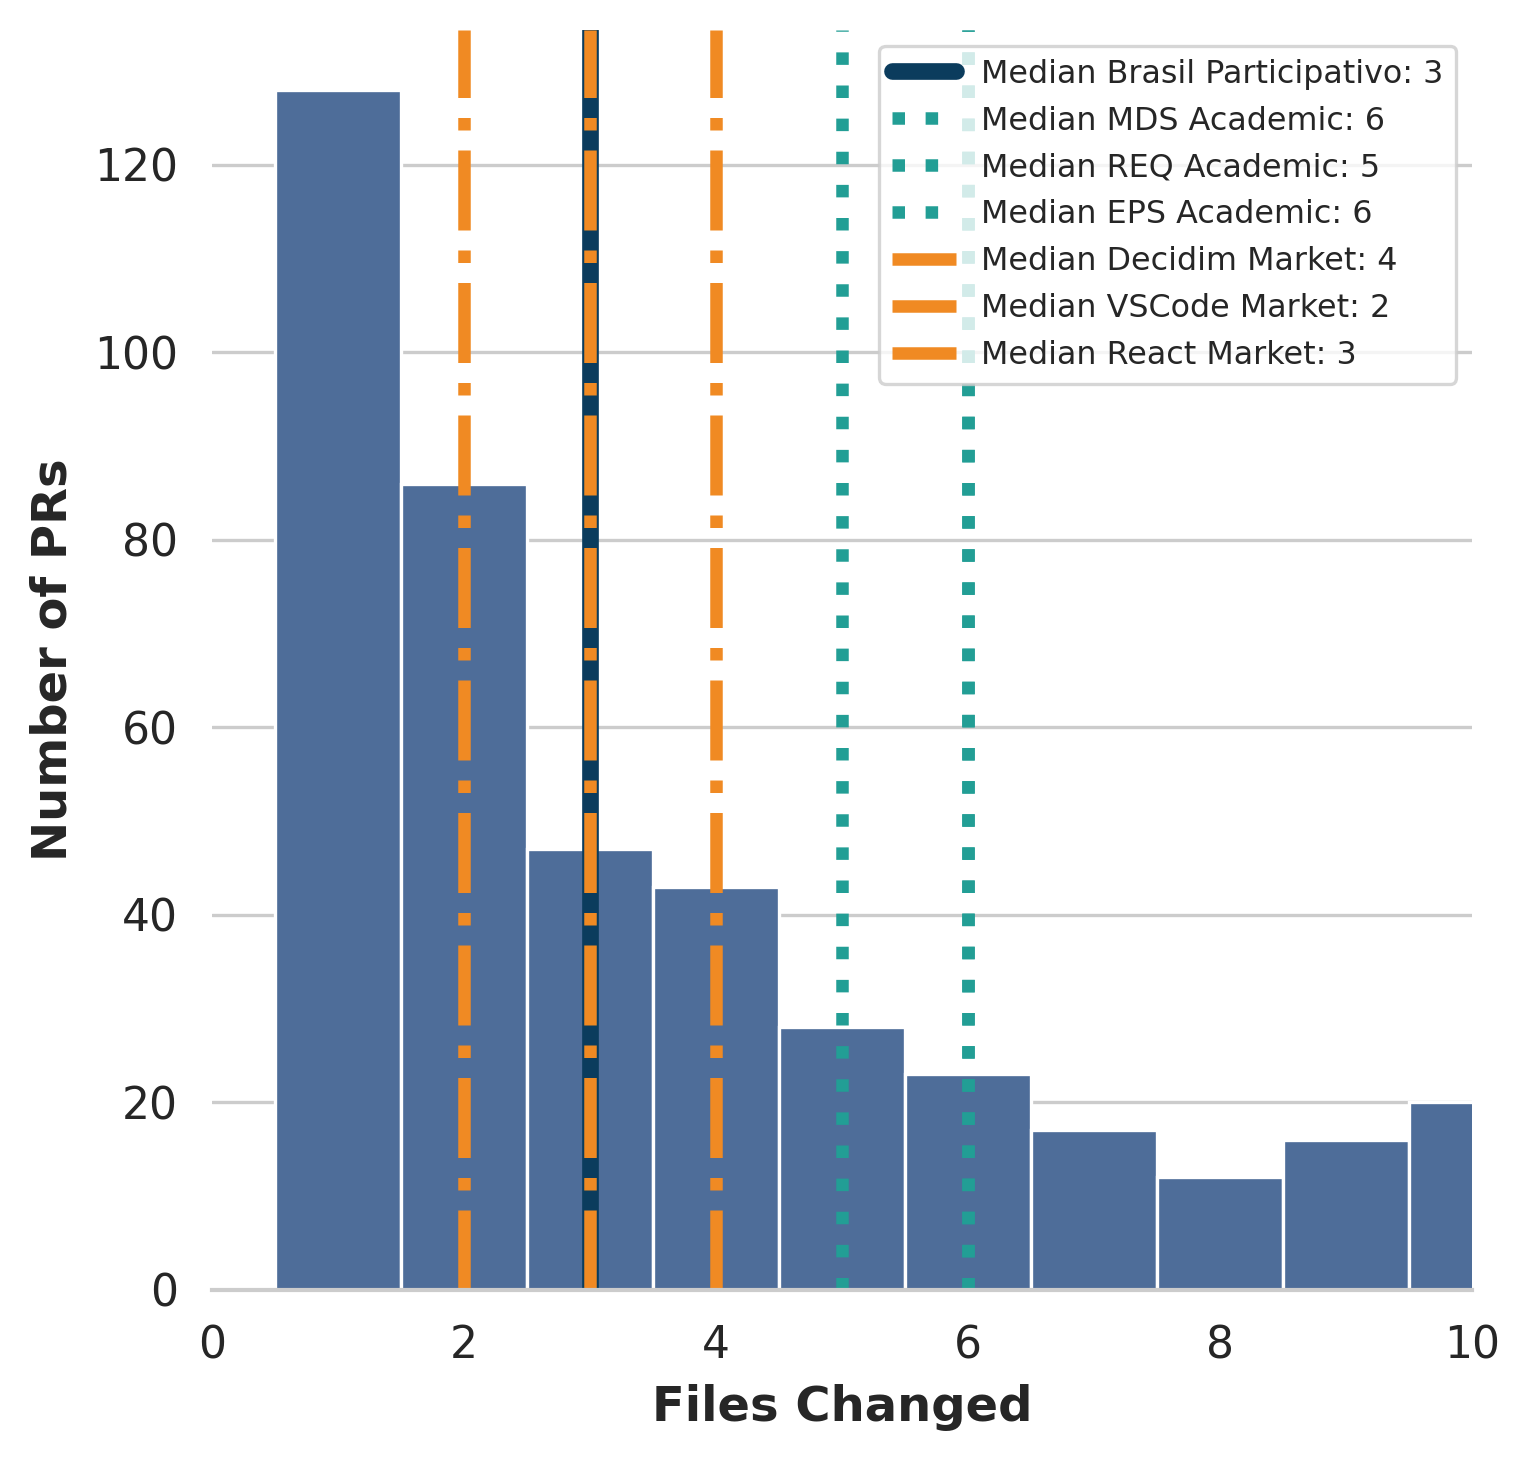

In [164]:
clean_lab = df_no_bots[(df_no_bots['files_changed'] > 0) & (df_no_bots['churn'] > 0)].copy()
clean_mds = df_mds_no_bots[(df_mds_no_bots['files_changed'] > 0) & (df_mds_no_bots['churn'] > 0)].copy()
clean_req = df_req_no_bots[(df_req_no_bots['files_changed'] > 0) & (df_req_no_bots['churn'] > 0)].copy()
clean_epsmds = df_epsmds_no_bots[(df_epsmds_no_bots['files_changed'] > 0) & (df_epsmds_no_bots['churn'] > 0)].copy()
clean_decidim = df_decidim_no_bots[(df_decidim_no_bots['files_changed'] > 0) & (df_decidim_no_bots['churn'] > 0)].copy()
clean_vscode = df_vscode_no_bots[(df_vscode_no_bots['files_changed'] > 0) & (df_vscode_no_bots['churn'] > 0)].copy()
clean_react = df_react_no_bots[(df_react_no_bots['files_changed'] > 0) & (df_react_no_bots['churn'] > 0)].copy()

p50_files_lab = clean_lab['files_changed'].median()
p50_files_mds = clean_mds['files_changed'].median()
p50_files_req = clean_req['files_changed'].median()
p50_files_epsmds = clean_epsmds['files_changed'].median()
p50_files_decidim = clean_decidim['files_changed'].median()
p50_files_vscode = clean_vscode['files_changed'].median()
p50_files_react = clean_react['files_changed'].median()
p50_churn_lab = clean_lab['churn'].median()
p50_churn_mds = clean_mds['churn'].median()
p50_churn_req = clean_req['churn'].median()
p50_churn_epsmds = clean_epsmds['churn'].median()
p50_churn_decidim = clean_decidim['churn'].median()
p50_churn_vscode = clean_vscode['churn'].median()
p50_churn_react = clean_react['churn'].median()

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

subset_files = clean_lab[clean_lab['files_changed'] <= 25]['files_changed']
sns.histplot(subset_files, discrete=True, color=BP_LIGHT, edgecolor='white', alpha=1.0, ax=ax1, kde=False, stat="count")

ax1.axvline(p50_files_lab, color=BP_PRIMARY, linewidth=4, label=f'Median {org_title}: {p50_files_lab:.0f}')
ax1.axvline(p50_files_mds, color=DISC_PRIMARY, linewidth=3, linestyle=':', label=f'Median {mds_title}: {p50_files_mds:.0f}')
ax1.axvline(p50_files_req, color=DISC_LIGHT, linewidth=3, linestyle=':', label=f'Median {req_title}: {p50_files_req:.0f}')
ax1.axvline(p50_files_epsmds, color=DISC_PRIMARY, linewidth=3, linestyle=':', label=f'Median {epsmds_title}: {p50_files_epsmds:.0f}')
ax1.axvline(p50_files_decidim, color=BENCH_PRIMARY, linewidth=3, linestyle='-.', label=f'Median {decidim_title}: {p50_files_decidim:.0f}')
ax1.axvline(p50_files_vscode, color=BENCH_MEDIUM, linewidth=3, linestyle='-.', label=f'Median {vscode_title}: {p50_files_vscode:.0f}')
ax1.axvline(p50_files_react, color=BENCH_PRIMARY, linewidth=3, linestyle='-.', label=f'Median {react_title}: {p50_files_react:.0f}')
ax1.set_box_aspect(1)

# ax1.set_title('Files Changed per PR — Brasil Participativo', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 10)
ax1.legend(fontsize='x-small', loc='upper right', frameon=True, framealpha=0.8)
ax1.set_xlabel('Files Changed', fontweight='bold')
ax1.set_ylabel('Number of PRs', fontweight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

ax1.grid(axis='x')

plt.tight_layout()
plt.show()

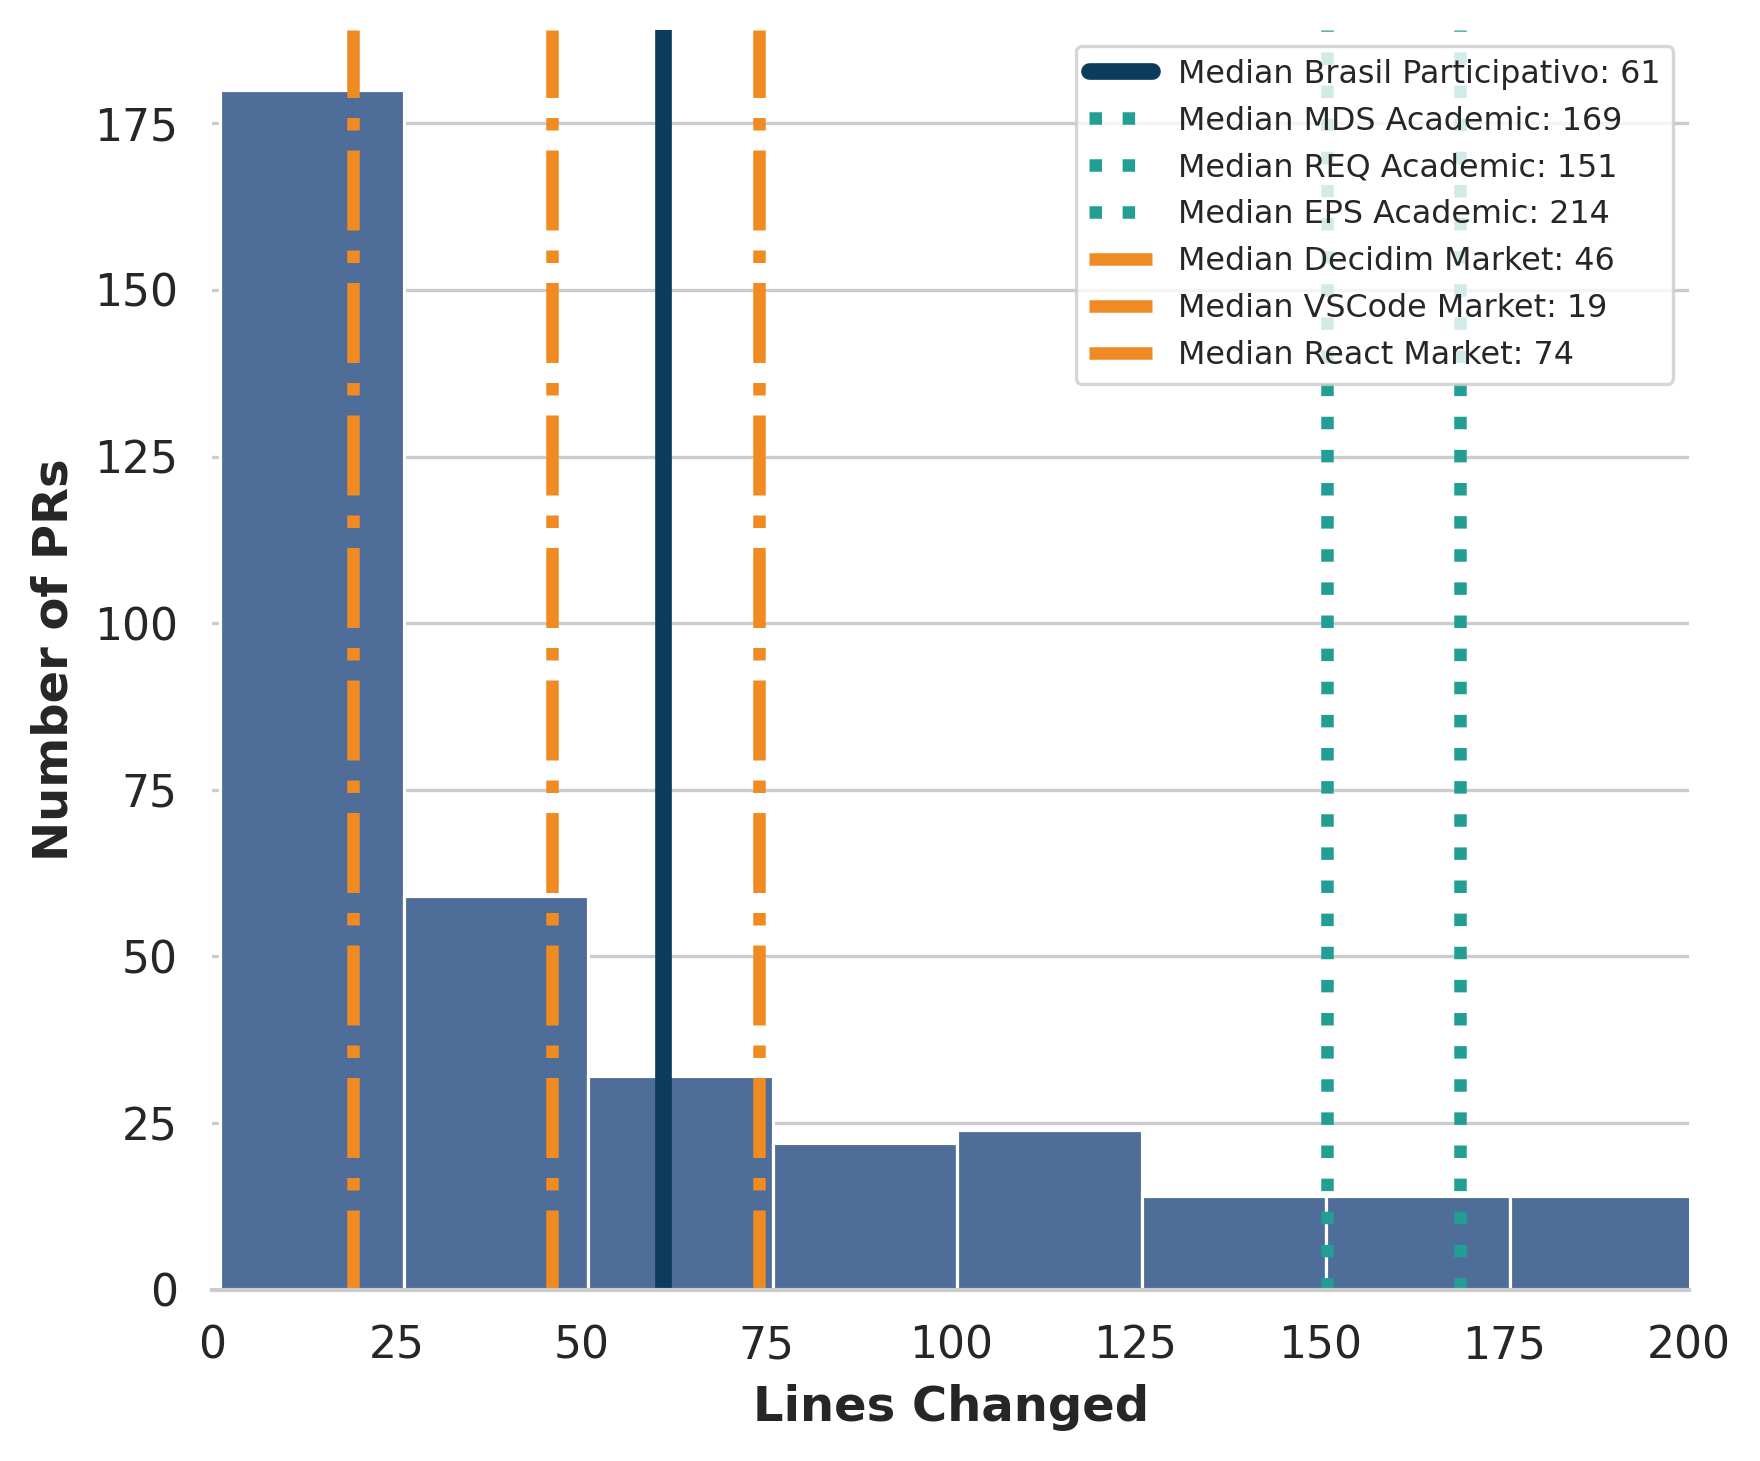

In [165]:
fig, ax2 = plt.subplots(figsize=(6, 5), dpi=300)

subset_churn = clean_lab[clean_lab['churn'] <= 1000]['churn']
sns.histplot(subset_churn, binwidth=25, kde=False, color=BP_LIGHT, edgecolor='white', alpha=1.0, ax=ax2)

ax2.axvline(p50_churn_lab, color=BP_PRIMARY, linewidth=4, label=f'Median {org_title}: {p50_churn_lab:.0f}')
ax2.axvline(p50_churn_mds, color=DISC_PRIMARY, linewidth=3, linestyle=':', label=f'Median {mds_title}: {p50_churn_mds:.0f}')
ax2.axvline(p50_churn_req, color=DISC_LIGHT, linewidth=3, linestyle=':', label=f'Median {req_title}: {p50_churn_req:.0f}')
ax2.axvline(p50_churn_epsmds, color=DISC_PRIMARY, linewidth=3, linestyle=':', label=f'Median {epsmds_title}: {p50_churn_epsmds:.0f}')
ax2.axvline(p50_churn_decidim, color=BENCH_PRIMARY, linewidth=3, linestyle='-.', label=f'Median {decidim_title}: {p50_churn_decidim:.0f}')
ax2.axvline(p50_churn_vscode, color=BENCH_MEDIUM, linewidth=3, linestyle='-.', label=f'Median {vscode_title}: {p50_churn_vscode:.0f}')
ax2.axvline(p50_churn_react, color=BENCH_PRIMARY, linewidth=3, linestyle='-.', label=f'Median {react_title}: {p50_churn_react:.0f}')
ax2.set_xlim(0, 200)
ax2.legend(fontsize='x-small', loc='upper right', frameon=True, framealpha=0.8)

# ax2.set_title('Lines per PR — Brasil Participativo', fontsize=14, fontweight='bold')

ax2.set_xlabel('Lines Changed', fontweight='bold')
ax2.set_ylabel('Number of PRs', fontweight='bold')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.grid(axis='x')

plt.tight_layout()
plt.show()

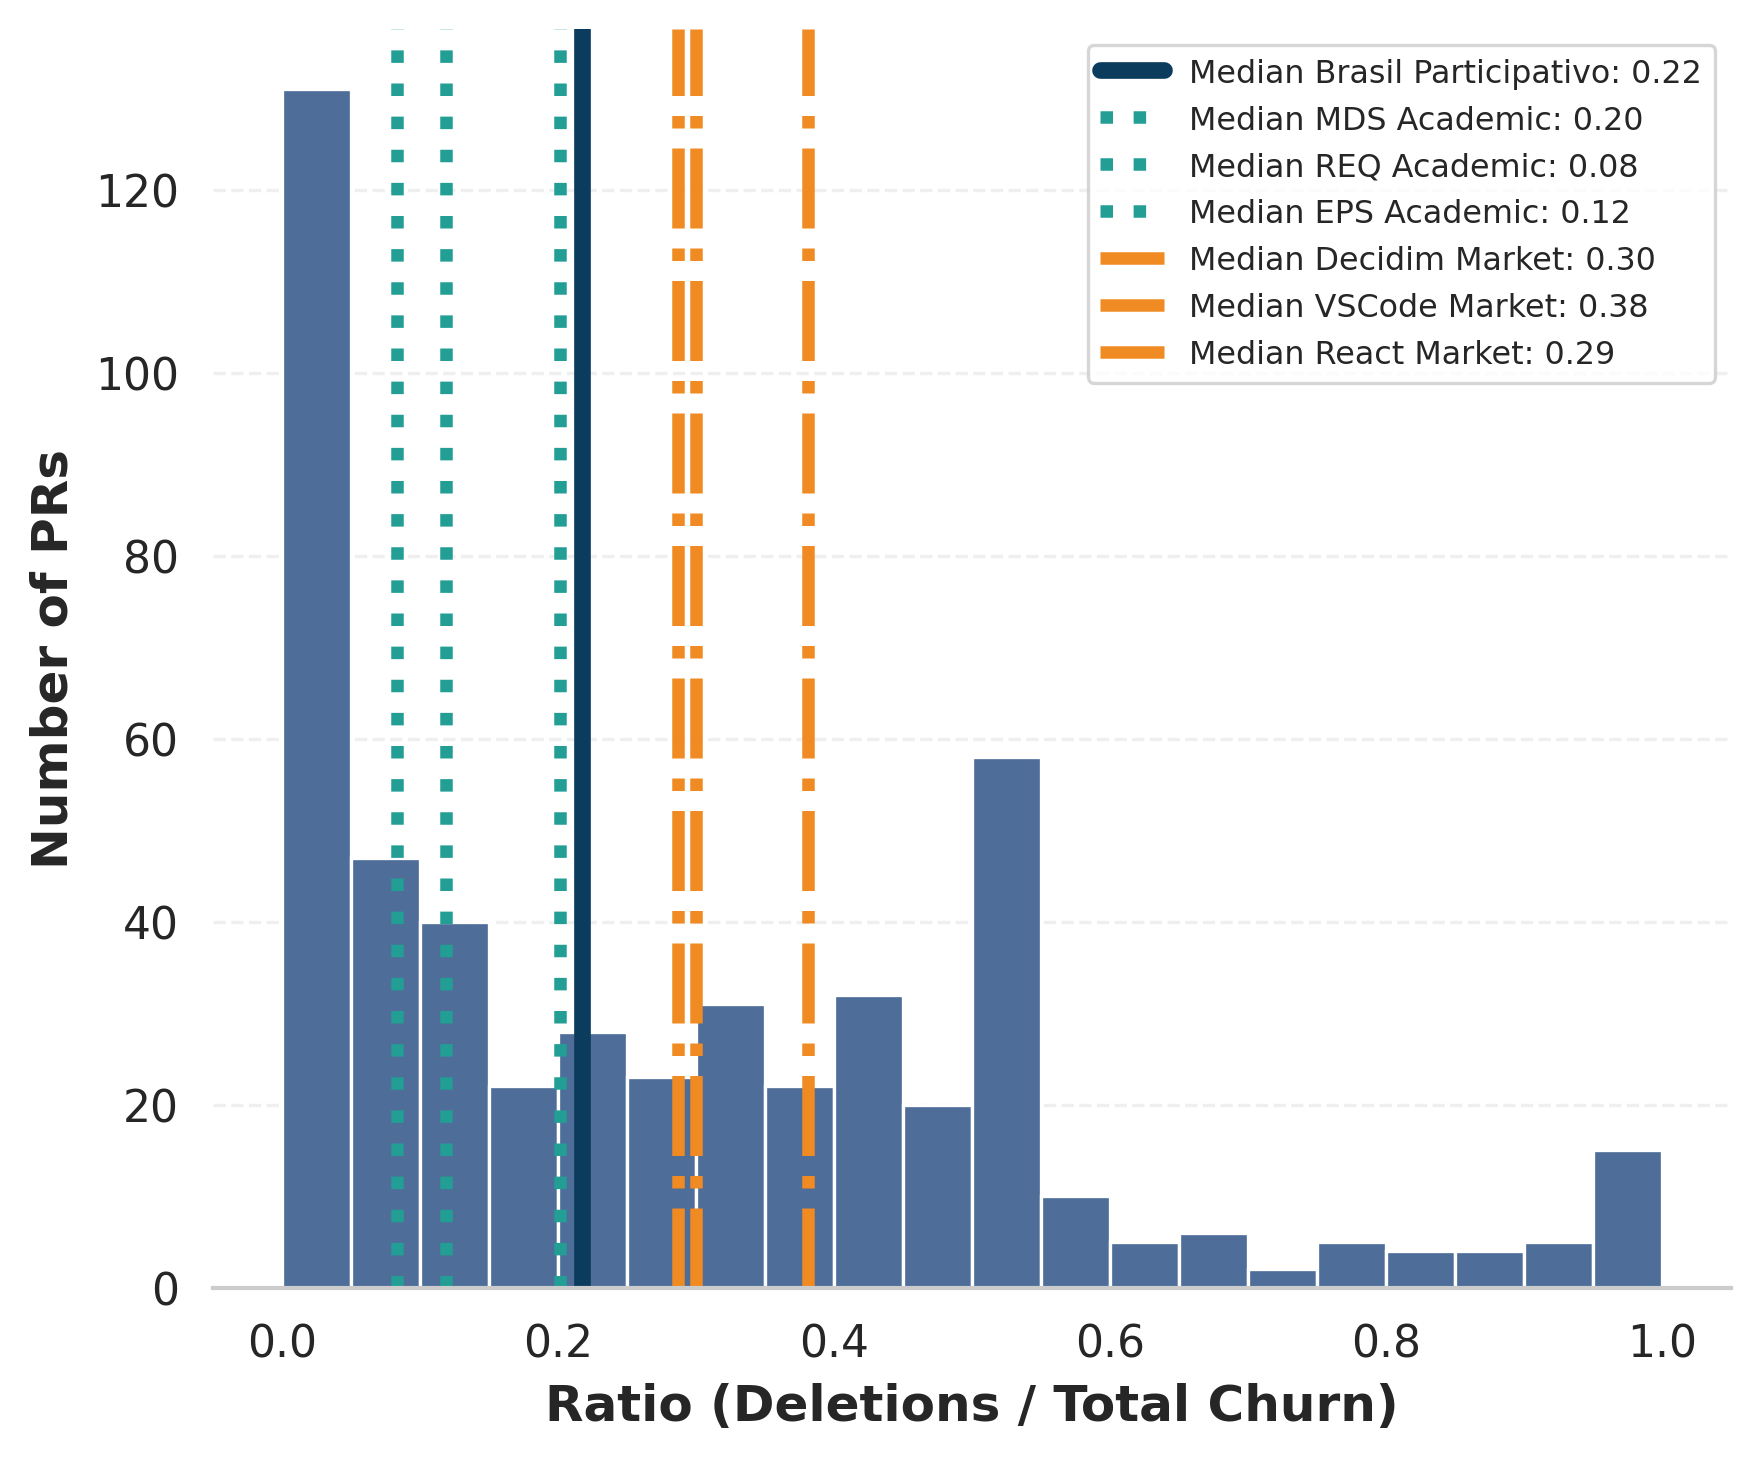

In [166]:
def plot_maintenance_patterns_comparison(df_bp, df_mds, df_req):
    def calculate_ratio(data):
        temp = data.copy()
        temp['refactor_ratio'] = temp.apply(lambda x: x['deletions'] / x['churn'] if x['churn'] > 0 else 0, axis=1)
        return temp

    df_bp_final = calculate_ratio(df_bp)
    df_mds_final = calculate_ratio(df_mds)
    df_req_final = calculate_ratio(df_req)
    df_epsmds_final = calculate_ratio(df_epsmds_no_bots)
    df_decidim_final = calculate_ratio(df_decidim_no_bots)
    df_vscode_final = calculate_ratio(df_vscode_no_bots)
    df_react_final = calculate_ratio(df_react_no_bots)

    med_bp = df_bp_final['refactor_ratio'].median()
    med_mds = df_mds_final['refactor_ratio'].median()
    med_req = df_req_final['refactor_ratio'].median()
    med_epsmds = df_epsmds_final['refactor_ratio'].median()
    med_decidim = df_decidim_final['refactor_ratio'].median()
    med_vscode = df_vscode_final['refactor_ratio'].median()
    med_react = df_react_final['refactor_ratio'].median()

    fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
    
    sns.histplot(df_bp_final['refactor_ratio'], kde=False, color=BP_LIGHT, edgecolor='white', 
                 bins=20, ax=ax, alpha=1.0)
    
    ax.axvline(med_bp, color=BP_PRIMARY, linewidth=4, label=f'Median {org_title}: {med_bp:.2f}')
    ax.axvline(med_mds, color=DISC_PRIMARY, linewidth=3, linestyle=':', label=f'Median {mds_title}: {med_mds:.2f}')
    ax.axvline(med_req, color=DISC_LIGHT, linewidth=3, linestyle=':', label=f'Median {req_title}: {med_req:.2f}')
    ax.axvline(med_epsmds, color=DISC_PRIMARY, linewidth=3, linestyle=':', label=f'Median {epsmds_title}: {med_epsmds:.2f}')
    ax.axvline(med_decidim, color=BENCH_PRIMARY, linewidth=3, linestyle='-.', label=f'Median {decidim_title}: {med_decidim:.2f}')
    ax.axvline(med_vscode, color=BENCH_MEDIUM, linewidth=3, linestyle='-.', label=f'Median {vscode_title}: {med_vscode:.2f}')
    ax.axvline(med_react, color=BENCH_PRIMARY, linewidth=3, linestyle='-.', label=f'Median {react_title}: {med_react:.2f}')
    
    # ax.set_title(f'{org_title} — Refactoring Ratio Distribution', fontsize=12, fontweight='bold', pad=20)
    ax.set_xlabel('Ratio (Deletions / Total Churn)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of PRs', fontsize=12, fontweight='bold')
    ax.legend(fontsize='x-small', loc='upper right', frameon=True, framealpha=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.grid(axis='x')
    
    plt.tight_layout()
    plt.show()

plot_maintenance_patterns_comparison(df_no_bots, df_mds_no_bots, df_req_no_bots)

/tmp/ipykernel_1376678/3153951782.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


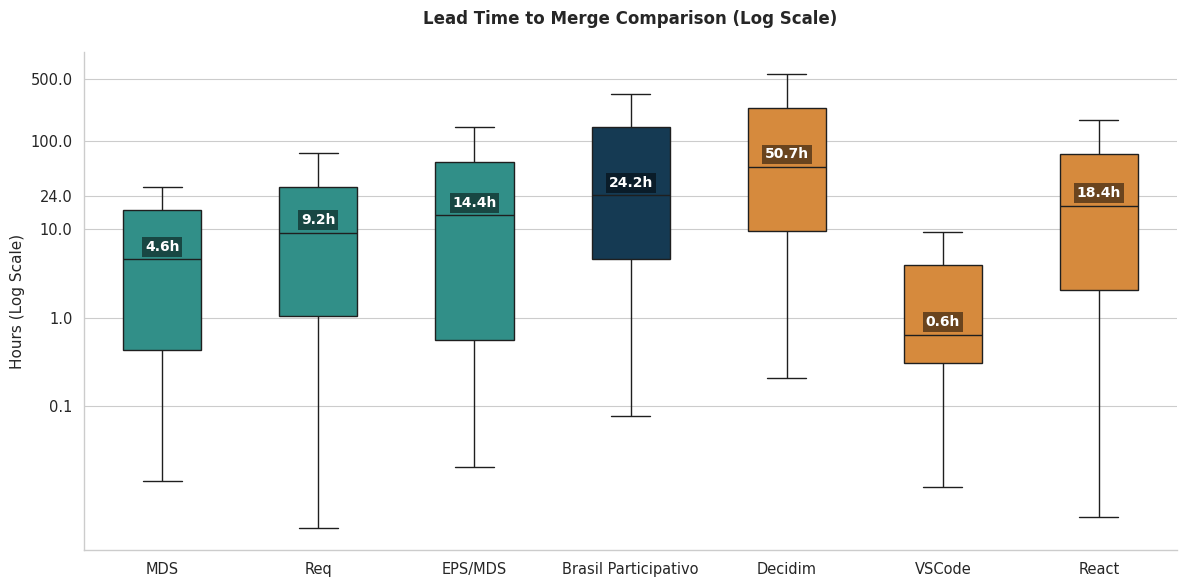

In [167]:
def count_human_reviewers_for_filter(reviewers_str):
    if pd.isna(reviewers_str) or reviewers_str == '':
        return 0
    bot_kw = ['github-actions', 'github-advanced-security', 'copilot-pull-request-reviewer',
              'dependabot', 'renovate', 'codecov', 'bot']
    reviewers = [r.strip().lower() for r in str(reviewers_str).split(',')]
    return sum(1 for r in reviewers if not any(bot in r for bot in bot_kw))

def plot_academic_log_boxplot(df_list, names):
    combined_data = []
    for df, name in zip(df_list, names):
        mask = (
            df['merged_at'].notna() & 
            (df['lead_time_hours'] > 0) & 
            (df['reviewers'].apply(count_human_reviewers_for_filter) > 0)
        )
        temp = df[mask].copy()
        temp['Project'] = name
        combined_data.append(temp[['lead_time_hours', 'Project']])

    df_plot = pd.concat(combined_data)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    
    colors = [DISC_PRIMARY, DISC_LIGHT, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_MEDIUM, BENCH_PRIMARY]

    sns.boxplot(
        x='Project', 
        y='lead_time_hours', 
        data=df_plot, 
        palette=colors,
        showfliers=False,
        width=0.5,
        ax=ax
    )
    
    ax.set_yscale("log")

    medians = df_plot.groupby(['Project'])['lead_time_hours'].median()
    for xtick in range(len(names)):
        val = medians[names[xtick]]
        ax.text(xtick, val*1.25, f'{val:.1f}h', 
                horizontalalignment='center', size=10, color='white', 
                weight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

    ax.set_title("Lead Time to Merge Comparison (Log Scale)", fontsize=12, fontweight='bold', pad=20)
    ax.set_ylabel("Hours (Log Scale)", fontsize=11)
    ax.set_xlabel("")
    
    ax.set_yticks([0.1, 1, 10, 24, 100, 500])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    
    sns.despine()
    plt.tight_layout()
    plt.show()

lista_dfs = [df_mds_no_bots, df_req_no_bots, df_epsmds_no_bots, df_no_bots, df_decidim_no_bots, df_vscode_no_bots, df_react_no_bots]
nomes = ["MDS", "Req", "EPS/MDS", "Brasil Participativo", "Decidim", "VSCode", "React"]

plot_academic_log_boxplot(lista_dfs, nomes)

/tmp/ipykernel_1376678/2756959681.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


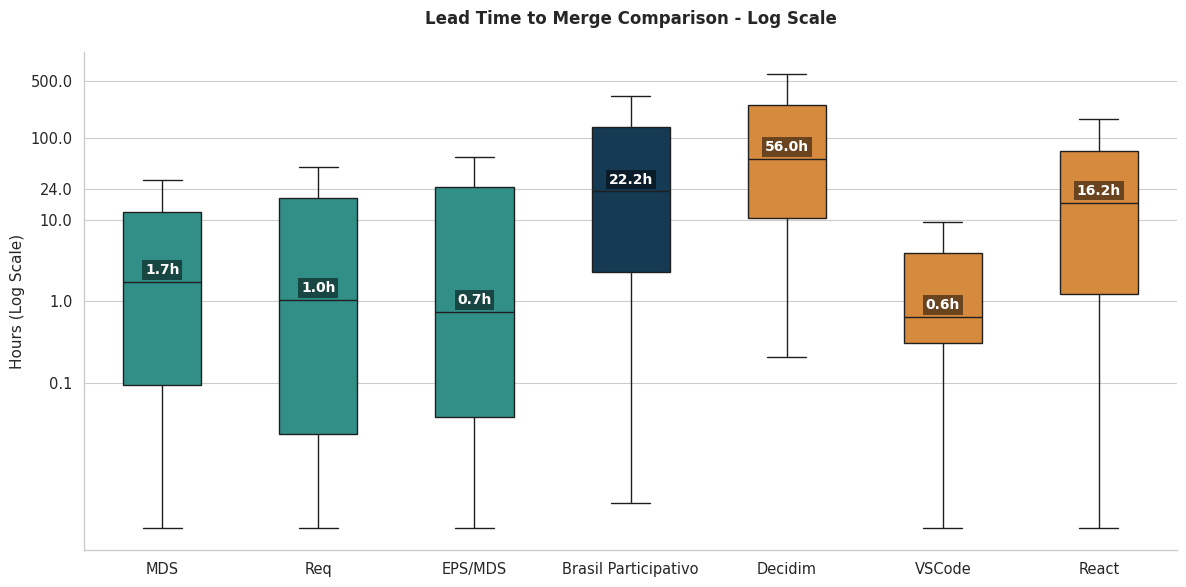

In [168]:
def plot_academic_log_boxplot(df_list, names):
    combined_data = []
    for df, name in zip(df_list, names):
        mask = (
            df['merged_at'].notna() & 
            (df['lead_time_hours'] > 0)
        )
        temp = df[mask].copy()
        temp['Project'] = name
        combined_data.append(temp[['lead_time_hours', 'Project']])

    df_plot = pd.concat(combined_data)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)
    
    colors = [DISC_PRIMARY, DISC_LIGHT, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_MEDIUM, BENCH_PRIMARY]

    sns.boxplot(
        x='Project', 
        y='lead_time_hours', 
        data=df_plot, 
        palette=colors,
        showfliers=False,
        width=0.5,
        ax=ax
    )
    
    ax.set_yscale("log")

    medians = df_plot.groupby(['Project'])['lead_time_hours'].median()
    for xtick in range(len(names)):
        val = medians[names[xtick]]
        ax.text(xtick, val*1.25, f'{val:.1f}h', 
                horizontalalignment='center', size=10, color='white', 
                weight='bold', bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

    ax.set_title("Lead Time to Merge Comparison - Log Scale", fontsize=12, fontweight='bold', pad=20)
    ax.set_ylabel("Hours (Log Scale)", fontsize=11)
    ax.set_xlabel("")
    
    ax.set_yticks([0.1, 1, 10, 24, 100, 500])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    
    sns.despine()
    plt.tight_layout()
    plt.show()

lista_dfs = [df_mds_no_bots, df_req_no_bots, df_epsmds_no_bots, df_no_bots, df_decidim_no_bots, df_vscode_no_bots, df_react_no_bots]
nomes = ["MDS", "Req", "EPS/MDS", "Brasil Participativo", "Decidim", "VSCode", "React"]

plot_academic_log_boxplot(lista_dfs, nomes)

/tmp/ipykernel_1376678/4031526486.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


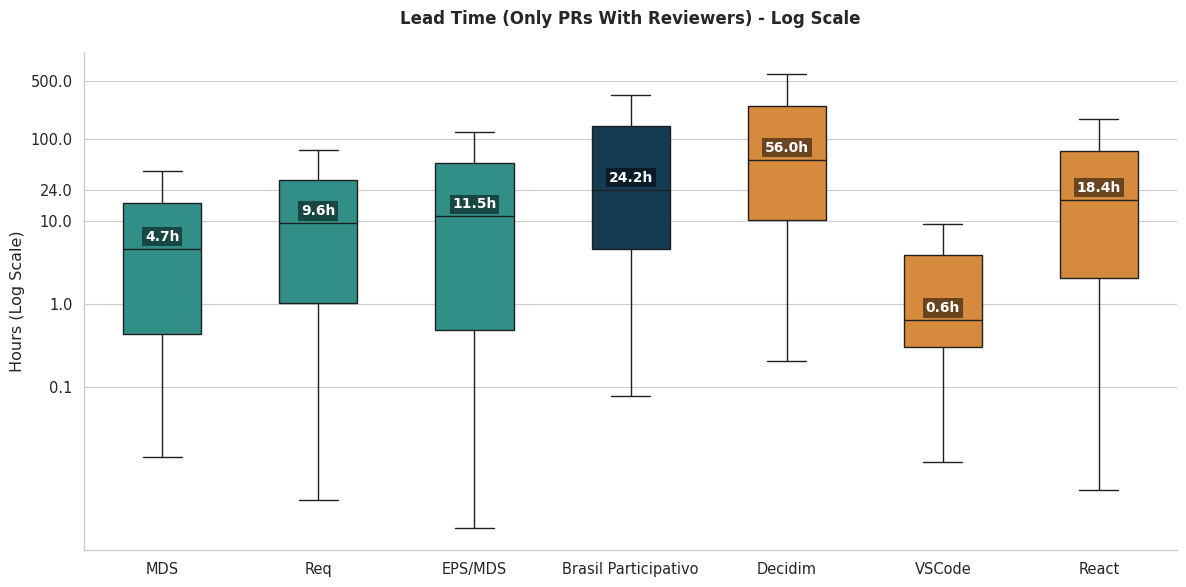

In [169]:
def plot_academic_log_boxplot_only_reviewed(df_list, names):
    combined_data = []
    
    for df, name in zip(df_list, names):
        
        reviewers_series = df['reviewers'].fillna("").astype(str)
        
        mask = (
            df['merged_at'].notna() &
            (df['lead_time_hours'] > 0) &
            (reviewers_series.str.strip() != "") 
        )
        
        temp = df[mask].copy()
        temp['Project'] = name
        combined_data.append(temp[['lead_time_hours', 'Project']])

    df_plot = pd.concat(combined_data)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    colors = [DISC_PRIMARY, DISC_LIGHT, DISC_PRIMARY, BP_PRIMARY, 
              BENCH_PRIMARY, BENCH_MEDIUM, BENCH_PRIMARY]

    sns.boxplot(
        x='Project',
        y='lead_time_hours',
        data=df_plot,
        palette=colors,
        showfliers=False,
        width=0.5,
        ax=ax
    )

    ax.set_yscale("log")

    medians = df_plot.groupby('Project')['lead_time_hours'].median()

    for xtick in range(len(names)):
        if names[xtick] in medians:
            val = medians[names[xtick]]
            ax.text(
                xtick, val * 1.25, f'{val:.1f}h',
                horizontalalignment='center',
                size=10,
                color='white',
                weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none')
            )

    ax.set_title("Lead Time (Only PRs With Reviewers) - Log Scale",
                 fontsize=12, fontweight='bold', pad=20)
    ax.set_ylabel("Hours (Log Scale)")
    ax.set_xlabel("")

    ax.set_yticks([0.1, 1, 10, 24, 100, 500])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

    sns.despine()
    plt.tight_layout()
    plt.show()


plot_academic_log_boxplot_only_reviewed(lista_dfs, nomes)

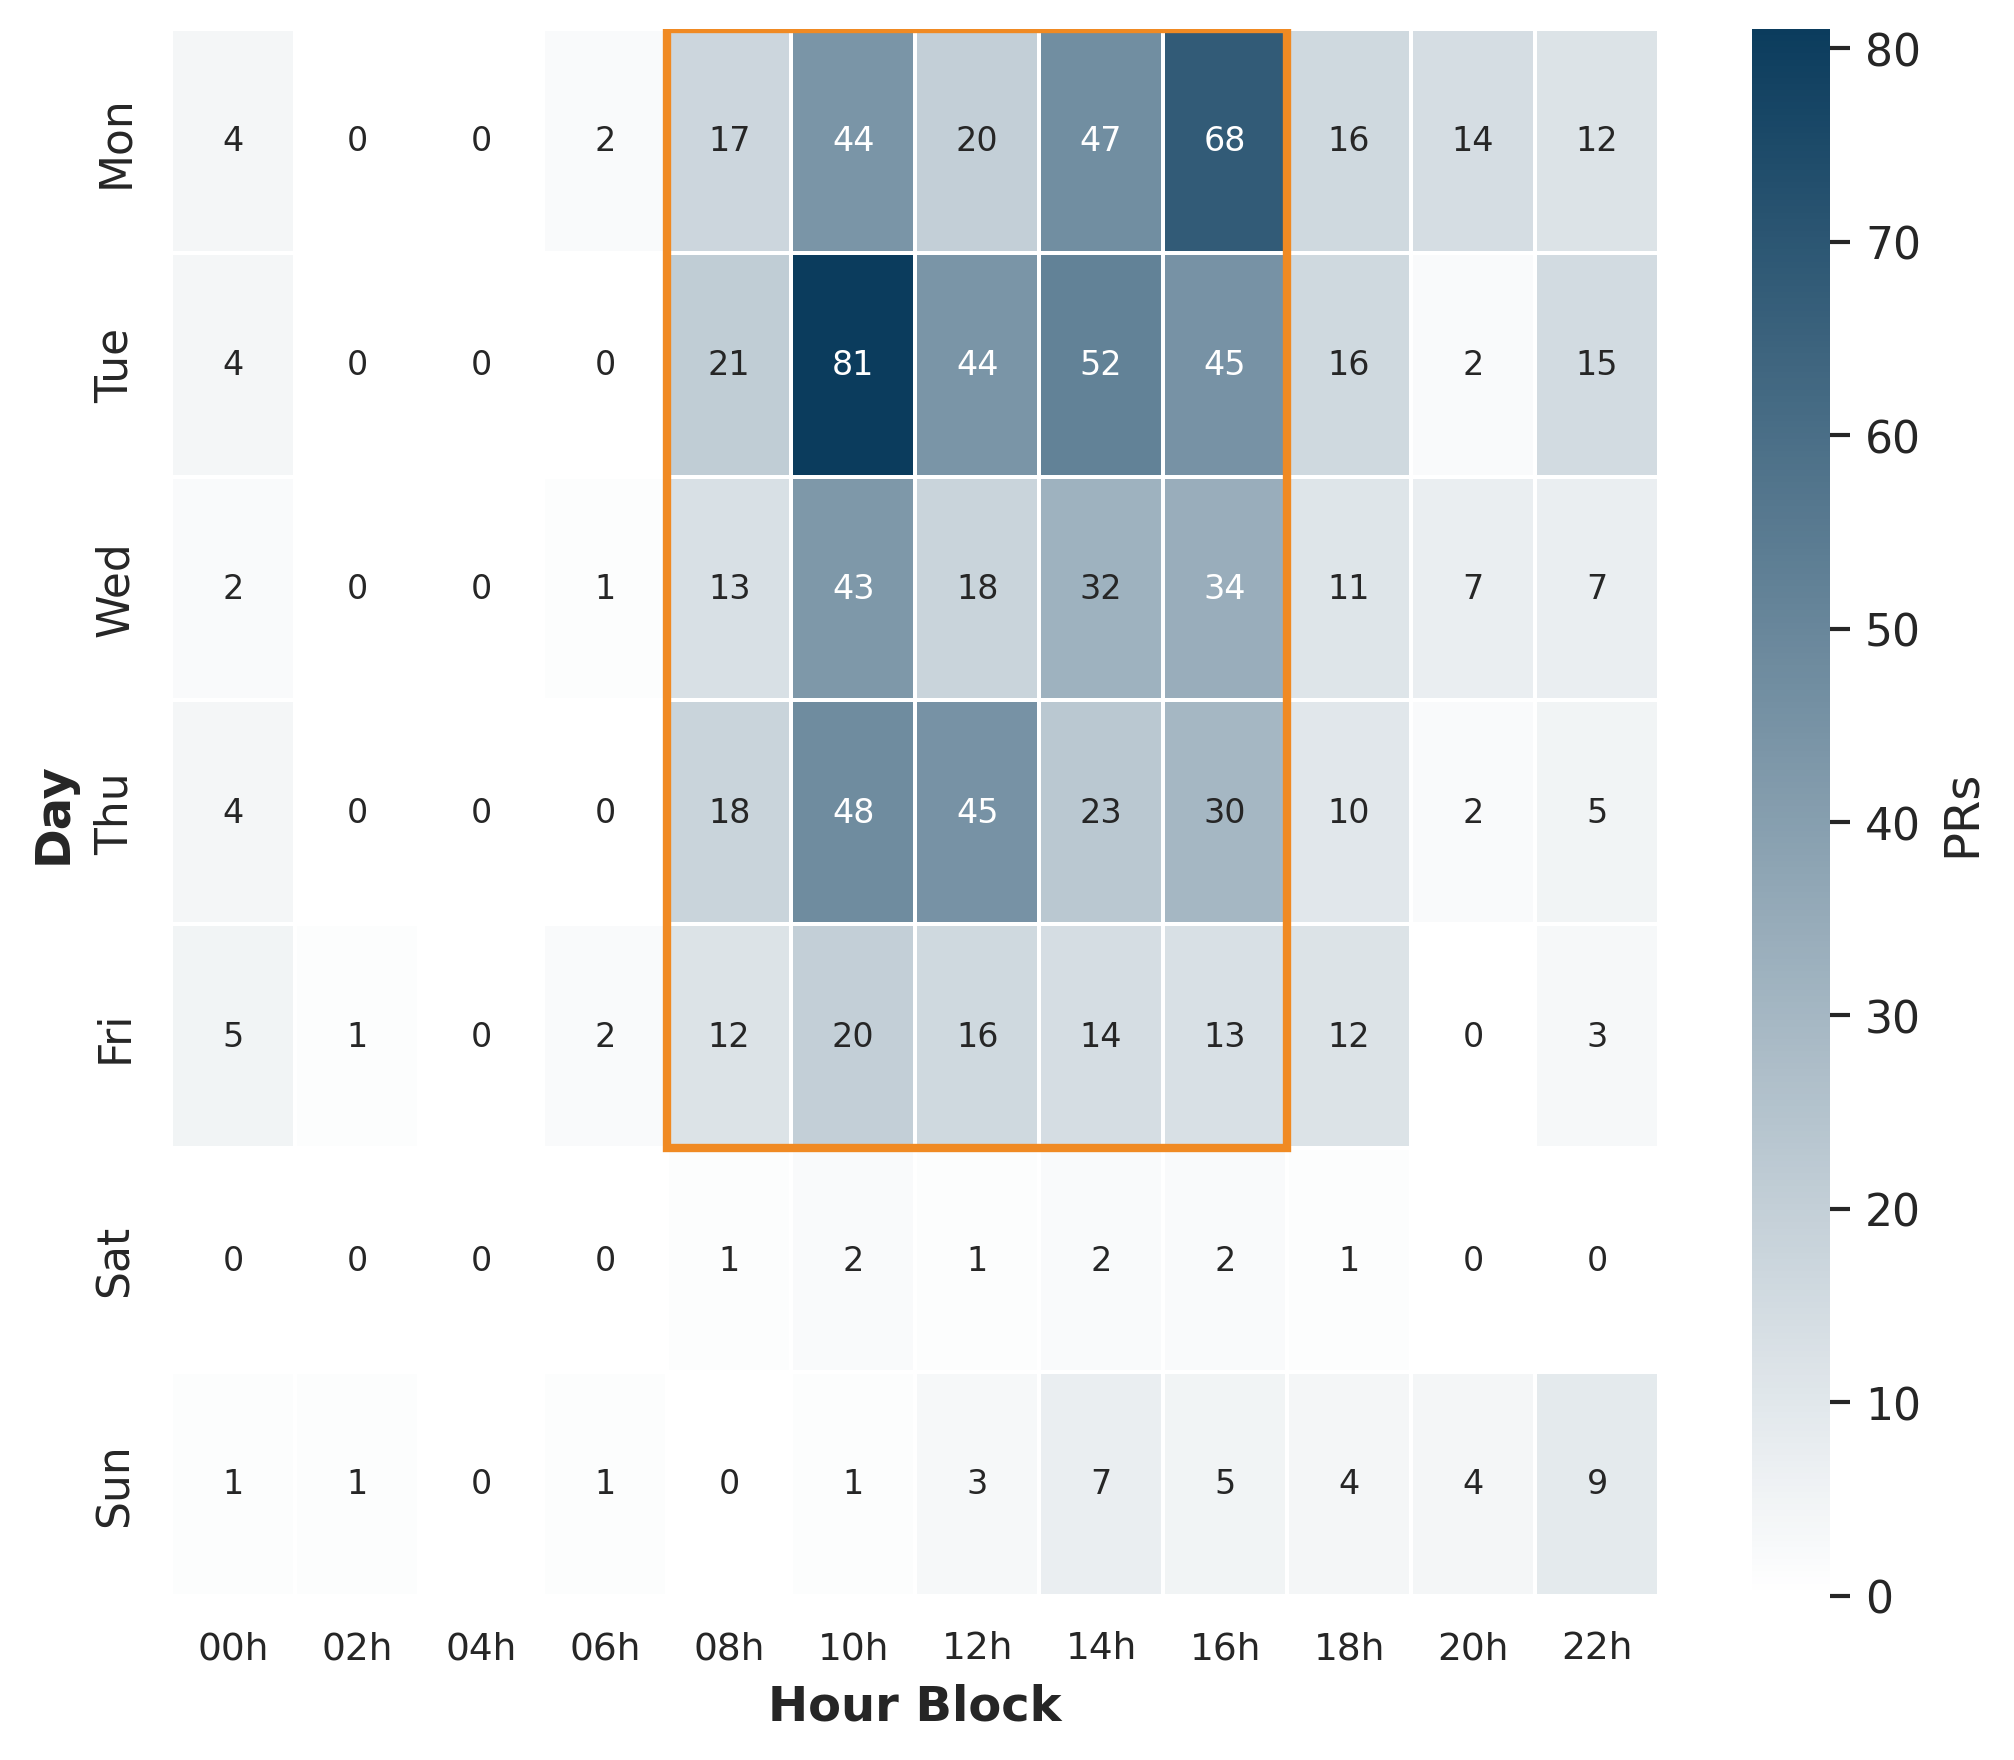

In [170]:
from matplotlib.patches import Rectangle

def prepare_data(data):
    data = data.copy()
    data['created_at'] = pd.to_datetime(data['created_at'], utc=True)
    data['merged_at'] = pd.to_datetime(data['merged_at'], utc=True)
    try:
        data['created_at_br'] = data['created_at'].dt.tz_convert('America/Sao_Paulo')
        data['merged_at_br'] = data['merged_at'].dt.tz_convert('America/Sao_Paulo')
    except:
        data['created_at_br'] = data['created_at']
        data['merged_at_br'] = data['merged_at']
    return data


def get_combined_heatmap_data(data):
    temp_created = data[['id', 'created_at_br']].dropna().copy()
    temp_created['day_name'] = temp_created['created_at_br'].dt.day_name()
    temp_created['hour'] = temp_created['created_at_br'].dt.hour

    temp_merged = data[['id', 'merged_at_br']].dropna().copy()
    temp_merged['day_name'] = temp_merged['merged_at_br'].dt.day_name()
    temp_merged['hour'] = temp_merged['merged_at_br'].dt.hour

    temp_combined = pd.concat([
        temp_created[['day_name', 'hour']],
        temp_merged[['day_name', 'hour']]
    ])

    pivot = temp_combined.groupby(['day_name', 'hour']).size().unstack(fill_value=0)

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot = pivot.reindex(days_order).fillna(0).astype(int)

    for h in range(24):
        if h not in pivot.columns:
            pivot[h] = 0

    return pivot[sorted(pivot.columns)]


# --- Prepare data once ---
df_bp_prepared = prepare_data(df_no_bots)
heatmap_bp = get_combined_heatmap_data(df_bp_prepared)

# Match academic format (short weekday labels)
heatmap_bp.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# --- Bin hours into 2-hour blocks ---
heatmap_bp_binned = heatmap_bp.T.groupby(
    np.arange(len(heatmap_bp.columns)) // 2
).sum().T

new_cols_bp = [f"{h:02d}h" for h in range(0, 24, 2)]
heatmap_bp_binned.columns = new_cols_bp


# --- Business hours rectangle ---
def add_business_hours_rect_binned(ax):
    rect = Rectangle(
        (4, 0),
        5, 5,
        linewidth=2,
        edgecolor=BENCH_MEDIUM,
        facecolor='none',
        linestyle='-',
        zorder=10
    )
    ax.add_patch(rect)


# --- Plot ---
cmap_bp = LinearSegmentedColormap.from_list("bp", ["#ffffff", BP_PRIMARY])

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    heatmap_bp_binned,
    cmap=cmap_bp,
    annot=True,
    fmt='d',
    linewidths=.5,
    ax=ax,
    cbar_kws={'label': 'PRs'},
    annot_kws={'size': 8}
)

# ax.set_title(f'{org_title}\nPRs Activity', fontsize=11, fontweight='bold')
ax.set_ylabel('Day', fontweight='bold')
ax.set_xlabel('Hour Block', fontweight='bold')

add_business_hours_rect_binned(ax)

plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


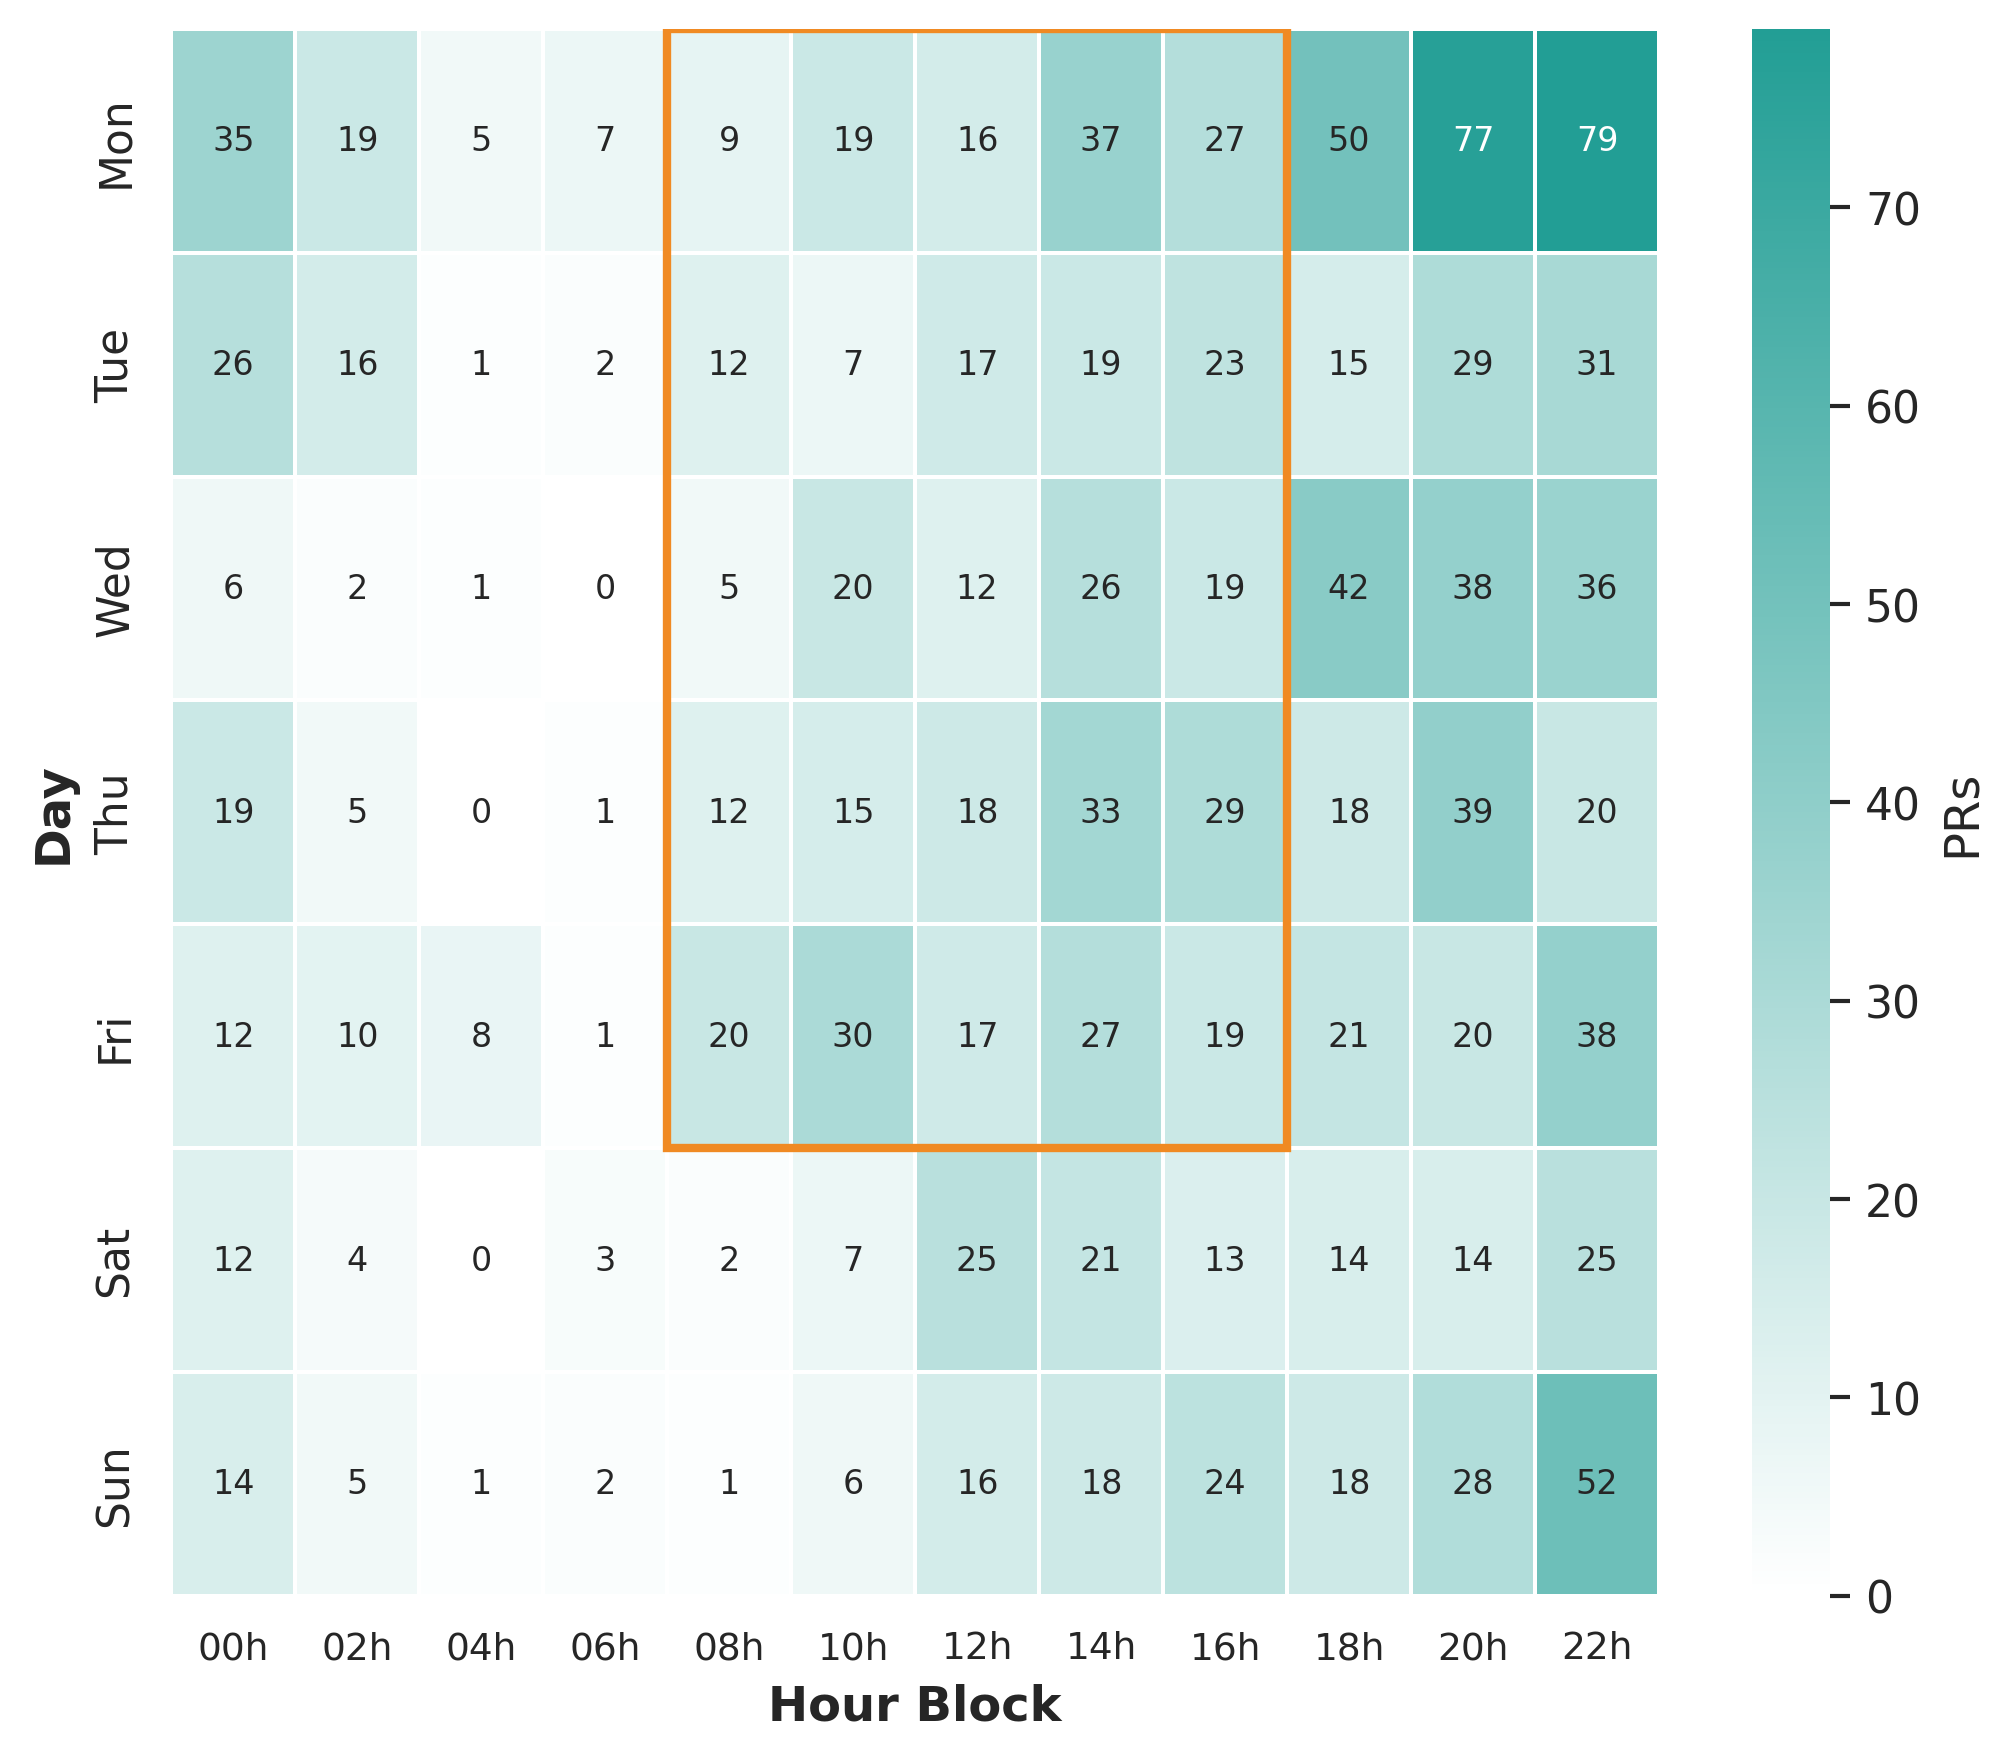

In [171]:
cmap_academic = LinearSegmentedColormap.from_list("academic", ["#ffffff", DISC_PRIMARY])
df_mds_prepared = prepare_data(df_mds_no_bots)
df_req_prepared = prepare_data(df_req_no_bots)
df_epsmds_prepared = prepare_data(df_epsmds_no_bots)
df_academic = pd.concat([df_mds_prepared, df_req_prepared, df_epsmds_prepared])
heatmap_academic = get_combined_heatmap_data(df_academic)

heatmap_academic.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

heatmap_binned = heatmap_academic.T.groupby(np.arange(len(heatmap_academic.columns)) // 2).sum().T

new_cols = [f"{h:02d}h" for h in range(0, 24, 2)]
heatmap_binned.columns = new_cols

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(heatmap_binned, cmap=cmap_academic, annot=True, fmt='d', linewidths=.5, ax=ax, 
            cbar_kws={'label': 'PRs'}, annot_kws={'size': 8})

# ax.set_title('Academic (MDS, REQ and EPS/MDS)\nPRs Activity', fontsize=11, fontweight='bold')
ax.set_ylabel('Day', fontweight='bold')
ax.set_xlabel('Hour Block', fontweight='bold')
add_business_hours_rect_binned(ax)
plt.xticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

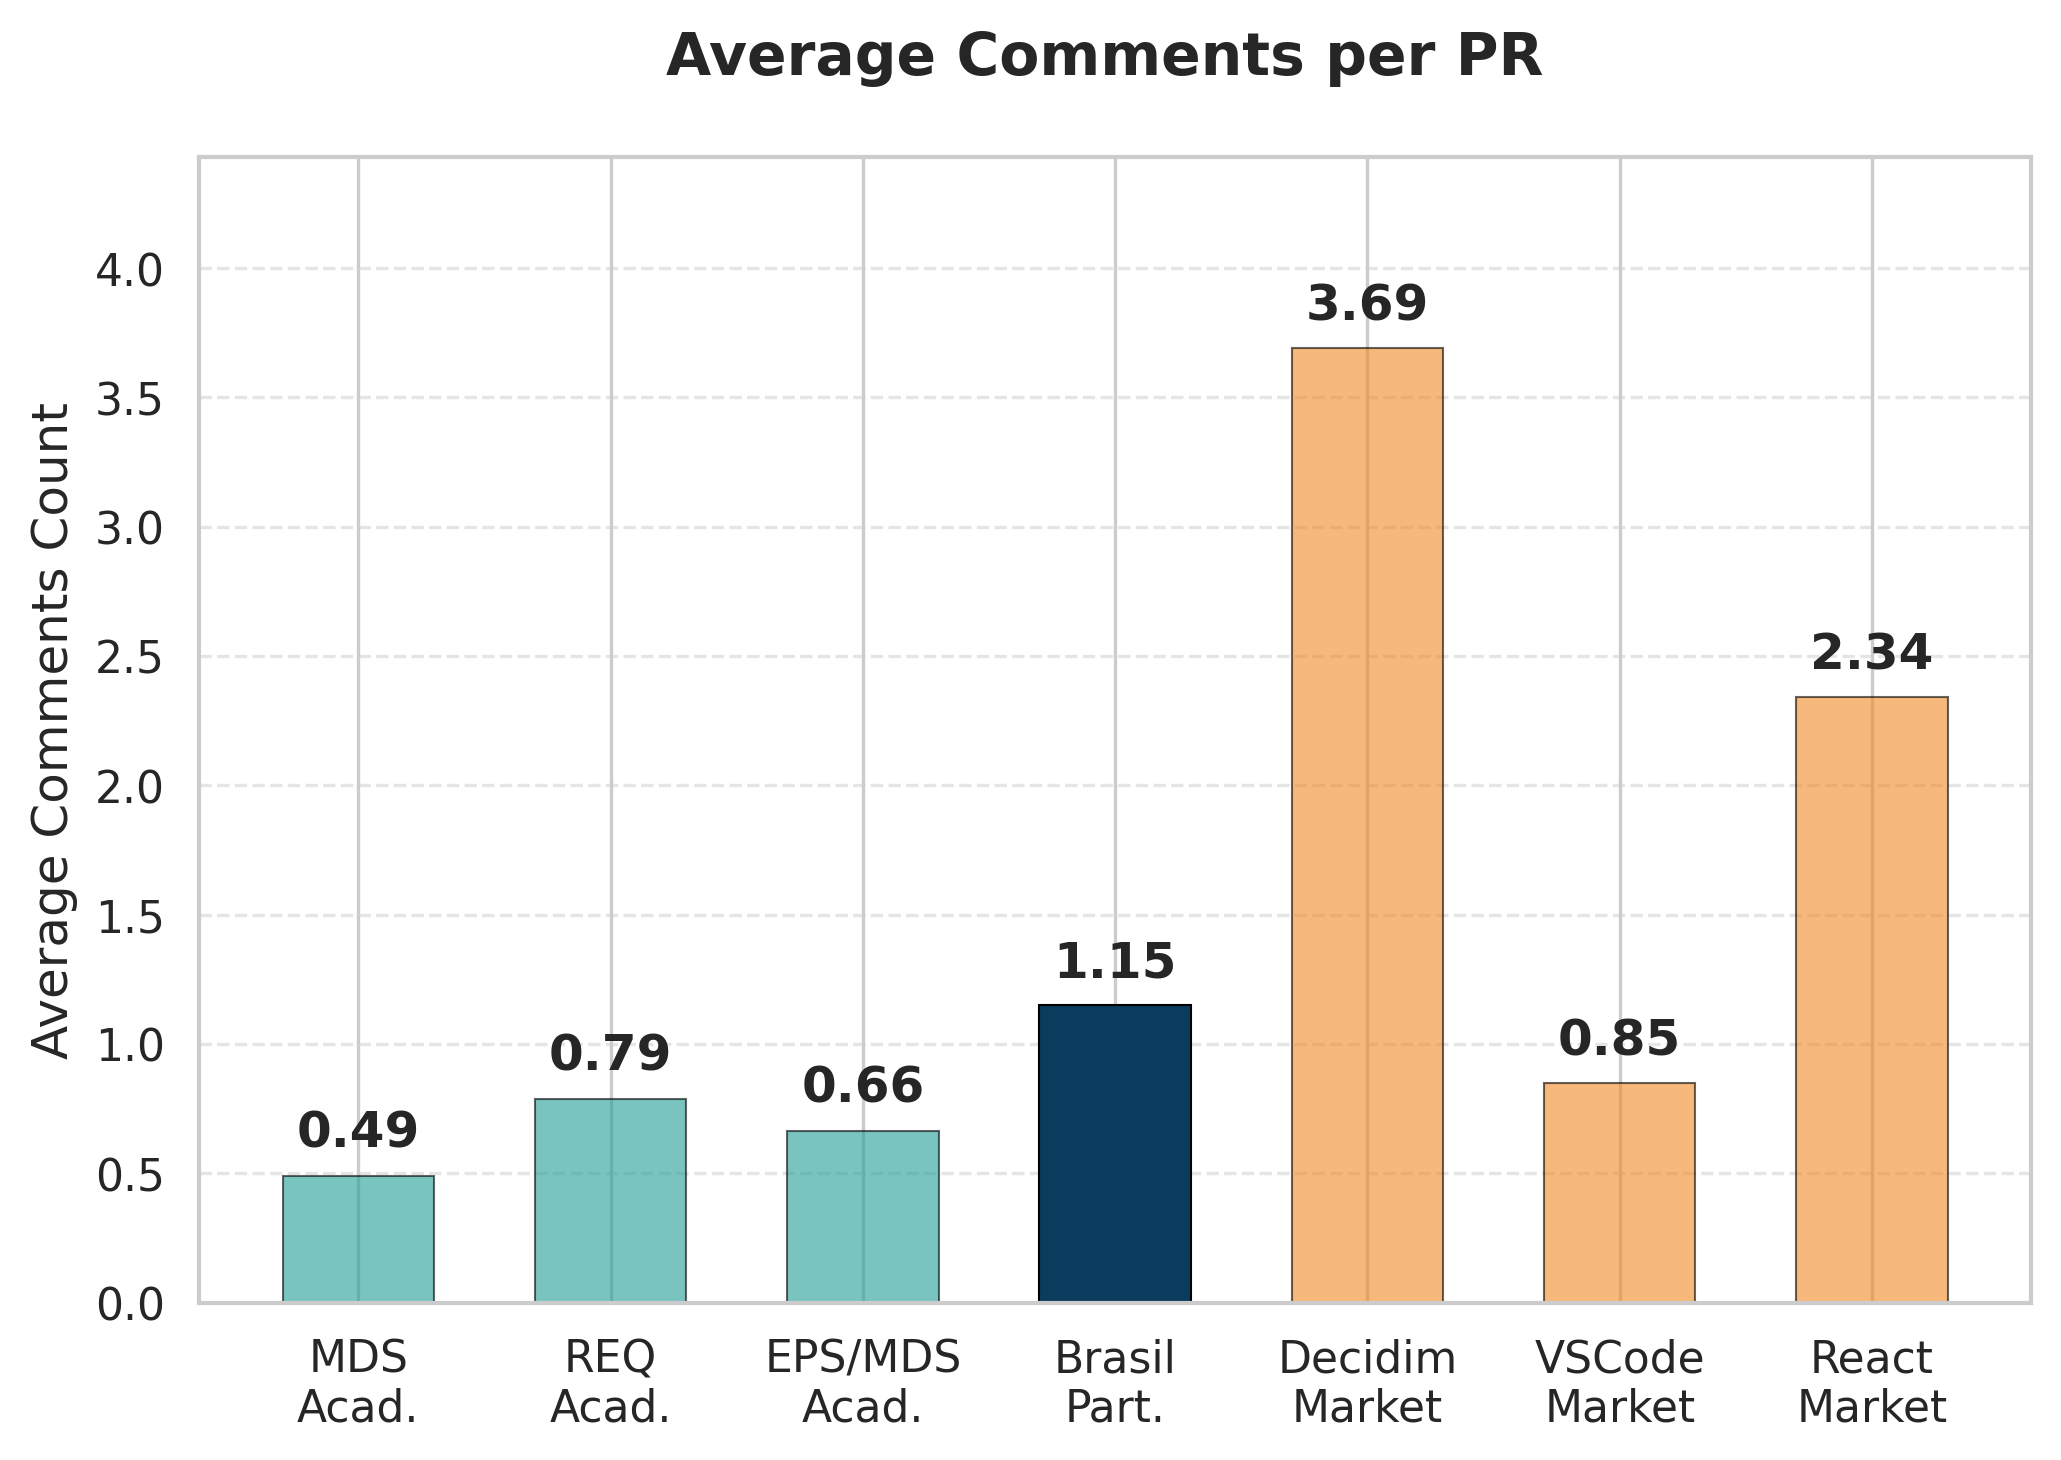

In [172]:
avg_comments_bp = df_no_bots['comments'].mean()
avg_comments_mds = df_mds_no_bots['comments'].mean()
avg_comments_req = df_req_no_bots['comments'].mean()
avg_comments_epsmds = df_epsmds_no_bots['comments'].mean()
avg_comments_decidim = df_decidim_no_bots['comments'].mean()
avg_comments_vscode = df_vscode_no_bots['comments'].mean()
avg_comments_react = df_react_no_bots['comments'].mean()

x_labels = [
    "MDS\nAcad.", 
    "REQ\nAcad.", 
    "EPS/MDS\nAcad.",
    "Brasil\nPart.", 
    "Decidim\nMarket", 
    "VSCode\nMarket",
    "React\nMarket"
]
y_values = [avg_comments_mds, avg_comments_req, avg_comments_epsmds, avg_comments_bp, avg_comments_decidim, avg_comments_vscode, avg_comments_react]
bar_colors = [DISC_PRIMARY, DISC_PRIMARY, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY]
bar_alphas = [0.6, 0.6, 0.6, 1.0, 0.6, 0.6, 0.6]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x_labels, y_values, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)

ax.set_title('Average Comments per PR ', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Average Comments Count', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(y_values) * 0.02),
            f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, max(y_values) * 1.2)
plt.tight_layout()
plt.show()

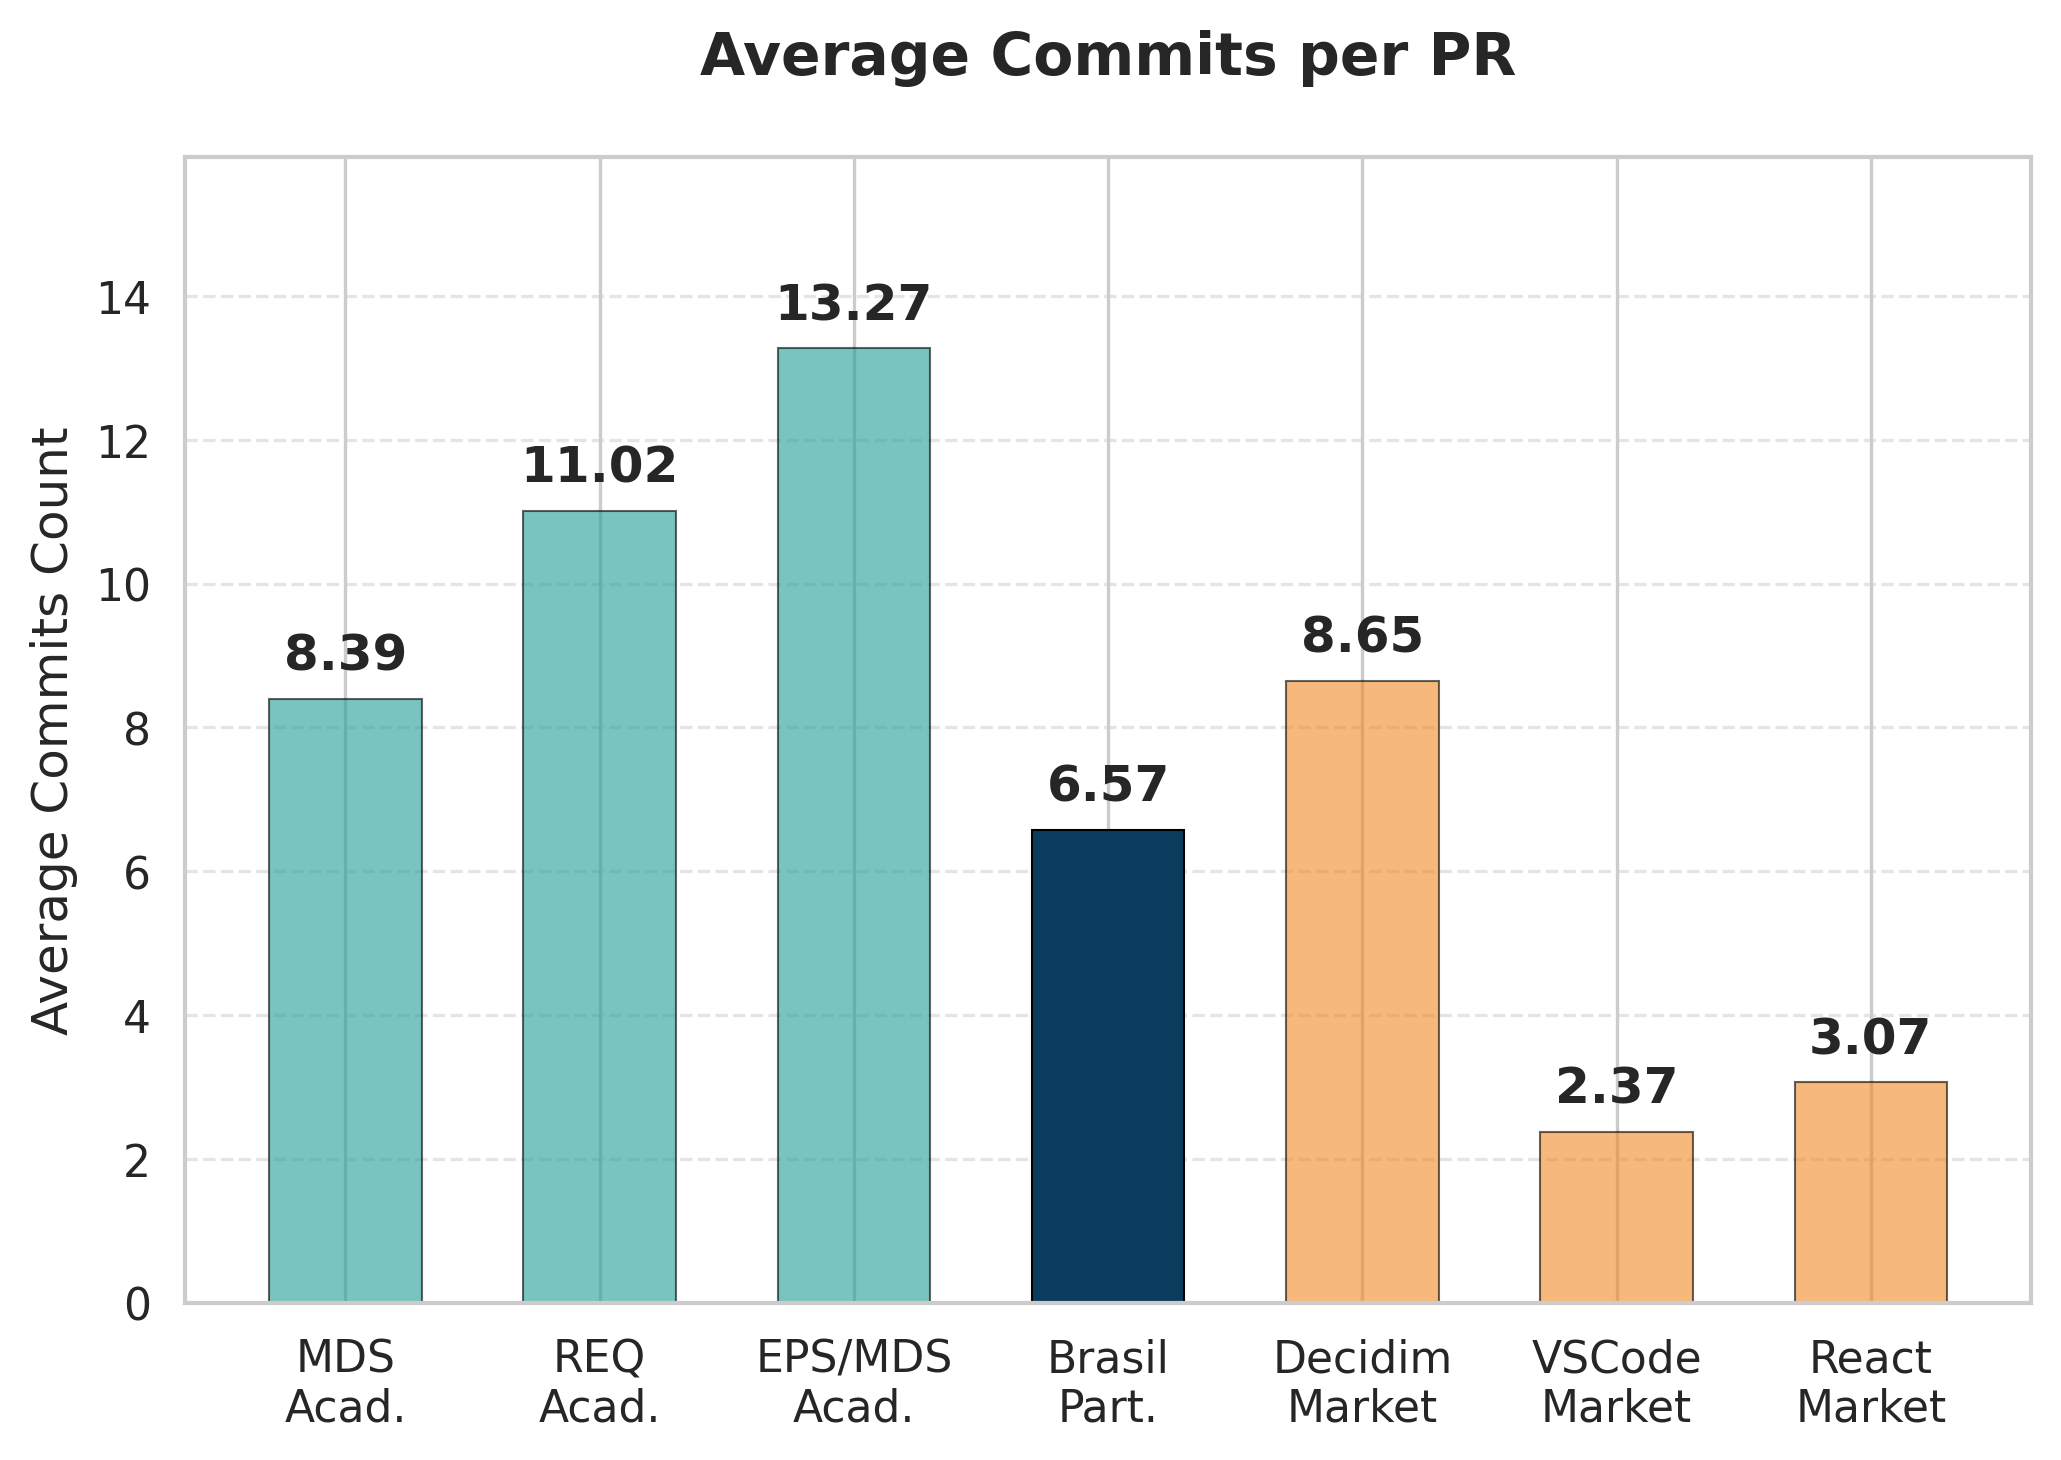

In [173]:
avg_commits_bp = df_no_bots['commits'].mean()
avg_commits_mds = df_mds_no_bots['commits'].mean()
avg_commits_req = df_req_no_bots['commits'].mean()
avg_commits_epsmds = df_epsmds_no_bots['commits'].mean()
avg_commits_decidim = df_decidim_no_bots['commits'].mean()
avg_commits_vscode = df_vscode_no_bots['commits'].mean()
avg_commits_react = df_react_no_bots['commits'].mean()

x_labels = [
    "MDS\nAcad.", 
    "REQ\nAcad.", 
    "EPS/MDS\nAcad.",
    "Brasil\nPart.", 
    "Decidim\nMarket", 
    "VSCode\nMarket",
    "React\nMarket"
]
y_values = [avg_commits_mds, avg_commits_req, avg_commits_epsmds, avg_commits_bp, avg_commits_decidim, avg_commits_vscode, avg_commits_react]
bar_colors = [DISC_PRIMARY, DISC_PRIMARY, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY]
bar_alphas = [0.6, 0.6, 0.6, 1.0, 0.6, 0.6, 0.6]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x_labels, y_values, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)

ax.set_title('Average Commits per PR', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Average Commits Count', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(y_values) * 0.02),
            f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, max(y_values) * 1.2)
plt.tight_layout()
plt.show()

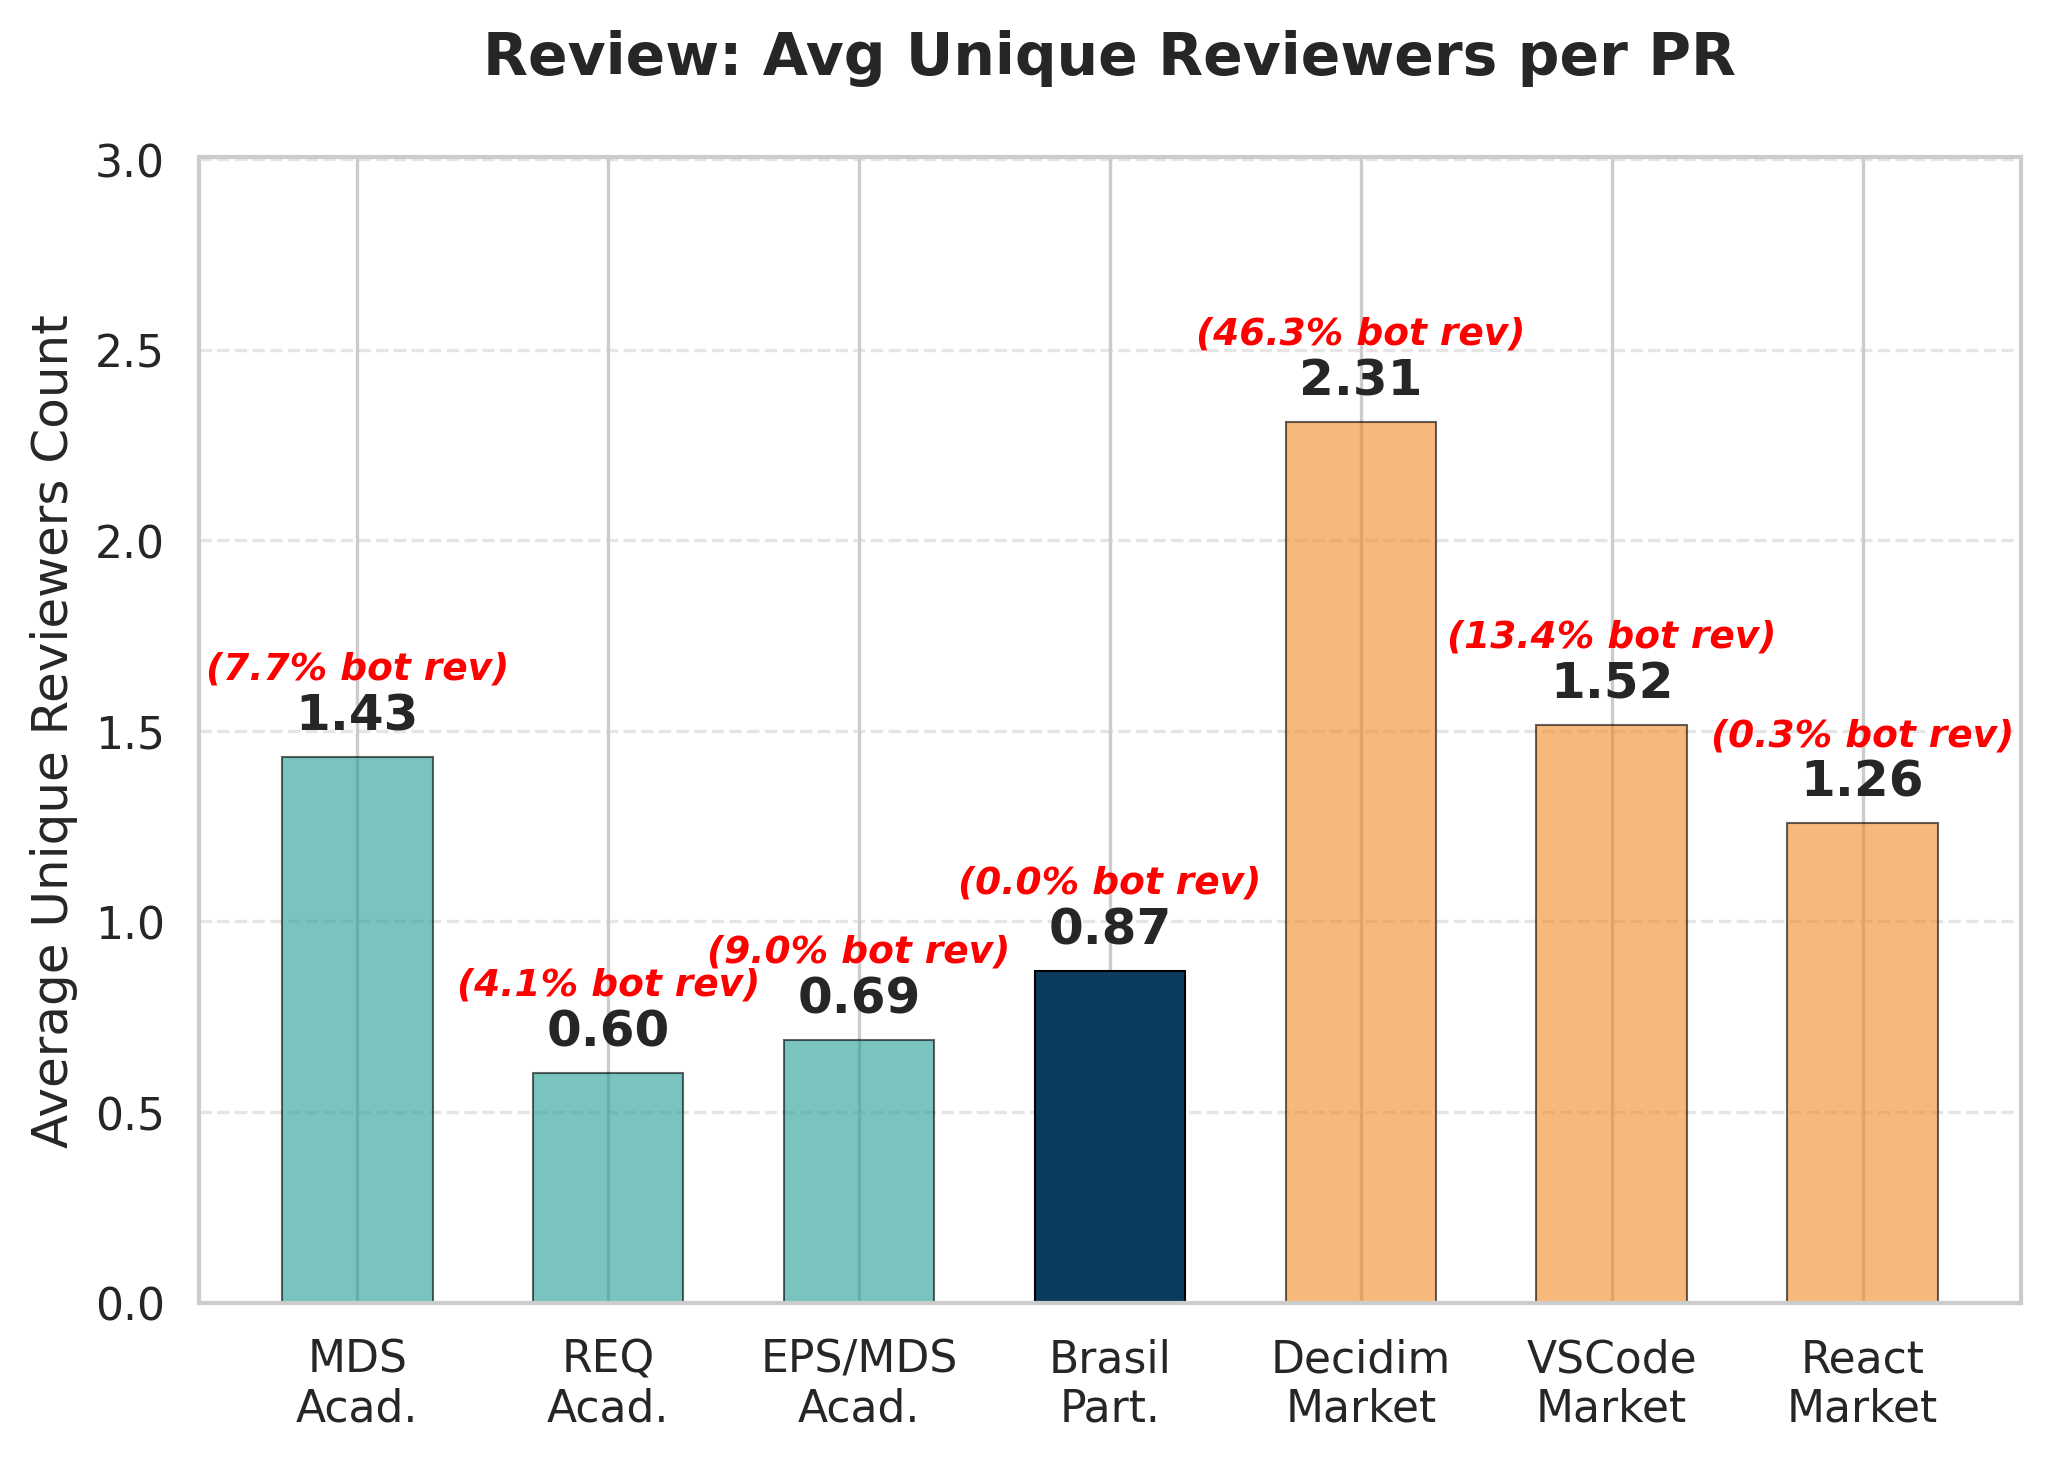

In [174]:
def count_unique_reviewers(reviewers_str):
    if pd.isna(reviewers_str) or reviewers_str == '':
        return 0
    return len(str(reviewers_str).split(','))

def count_bot_reviewers(reviewers_str):
    if pd.isna(reviewers_str) or reviewers_str == '':
        return 0
    bot_kw = ['github-actions', 'github-advanced-security', 'copilot-pull-request-reviewer',
              'dependabot', 'renovate', 'codecov']
    reviewers = [r.strip().lower() for r in str(reviewers_str).split(',')]
    return sum(1 for r in reviewers if any(bot in r for bot in bot_kw))

for d in [df_no_bots, df_mds_no_bots, df_req_no_bots, df_epsmds_no_bots, df_decidim_no_bots, df_vscode_no_bots, df_react_no_bots]:
    d['num_reviewers'] = d['reviewers'].apply(count_unique_reviewers)

df_rev_bp = df_no_bots[df_no_bots['reviewers'].notna() & (df_no_bots['reviewers'] != '')].copy()
df_rev_mds = df_mds_no_bots[df_mds_no_bots['reviewers'].notna() & (df_mds_no_bots['reviewers'] != '')].copy()
df_rev_req = df_req_no_bots[df_req_no_bots['reviewers'].notna() & (df_req_no_bots['reviewers'] != '')].copy()
df_rev_epsmds = df_epsmds_no_bots[df_epsmds_no_bots['reviewers'].notna() & (df_epsmds_no_bots['reviewers'] != '')].copy()
df_rev_decidim = df_decidim_no_bots[df_decidim_no_bots['reviewers'].notna() & (df_decidim_no_bots['reviewers'] != '')].copy()
df_rev_vscode = df_vscode_no_bots[df_vscode_no_bots['reviewers'].notna() & (df_vscode_no_bots['reviewers'] != '')].copy()
df_rev_react = df_react_no_bots[df_react_no_bots['reviewers'].notna() & (df_react_no_bots['reviewers'] != '')].copy()

bot_reviewers_bp = df_rev_bp['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_bp) > 0 else 0
bot_reviewers_mds = df_rev_mds['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_mds) > 0 else 0
bot_reviewers_req = df_rev_req['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_req) > 0 else 0
bot_reviewers_epsmds = df_rev_epsmds['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_epsmds) > 0 else 0
bot_reviewers_decidim = df_rev_decidim['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_decidim) > 0 else 0
bot_reviewers_vscode = df_rev_vscode['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_vscode) > 0 else 0
bot_reviewers_react = df_rev_react['reviewers'].apply(count_bot_reviewers).mean() if len(df_rev_react) > 0 else 0

avg_unique_reviewers_bp = df_no_bots['num_reviewers'].mean()
avg_unique_reviewers_mds = df_mds_no_bots['num_reviewers'].mean()
avg_unique_reviewers_req = df_req_no_bots['num_reviewers'].mean()
avg_unique_reviewers_epsmds = df_epsmds_no_bots['num_reviewers'].mean()
avg_unique_reviewers_decidim = df_decidim_no_bots['num_reviewers'].mean()
avg_unique_reviewers_vscode = df_vscode_no_bots['num_reviewers'].mean()
avg_unique_reviewers_react = df_react_no_bots['num_reviewers'].mean()

x_labels = [
    "MDS\nAcad.", 
    "REQ\nAcad.", 
    "EPS/MDS\nAcad.",
    "Brasil\nPart.", 
    "Decidim\nMarket", 
    "VSCode\nMarket",
    "React\nMarket"
]
total_values = [avg_unique_reviewers_mds, avg_unique_reviewers_req, avg_unique_reviewers_epsmds, avg_unique_reviewers_bp,
                avg_unique_reviewers_decidim, avg_unique_reviewers_vscode, avg_unique_reviewers_react]
bot_values = [bot_reviewers_mds, bot_reviewers_req, bot_reviewers_epsmds, bot_reviewers_bp,
              bot_reviewers_decidim, bot_reviewers_vscode, bot_reviewers_react]
bar_colors = [DISC_PRIMARY, DISC_PRIMARY, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY]
bar_alphas = [0.6, 0.6, 0.6, 1.0, 0.6, 0.6, 0.6]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x_labels, total_values, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars, bar_alphas):
    bar.set_alpha(alpha)

ax.set_title('Review: Avg Unique Reviewers per PR', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Average Unique Reviewers Count', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, (bar, total, bot) in enumerate(zip(bars, total_values, bot_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(total_values) * 0.02),
            f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    bot_pct = (bot / total * 100) if total > 0 else 0
    ax.text(bar.get_x() + bar.get_width()/2., height + (max(total_values) * 0.08),
            f'({bot_pct:.1f}% bot rev)', ha='center', va='bottom', fontsize=9,
            color='red', style='italic', fontweight='bold')

ax.set_ylim(0, max(total_values) * 1.3)
plt.tight_layout()
plt.show()

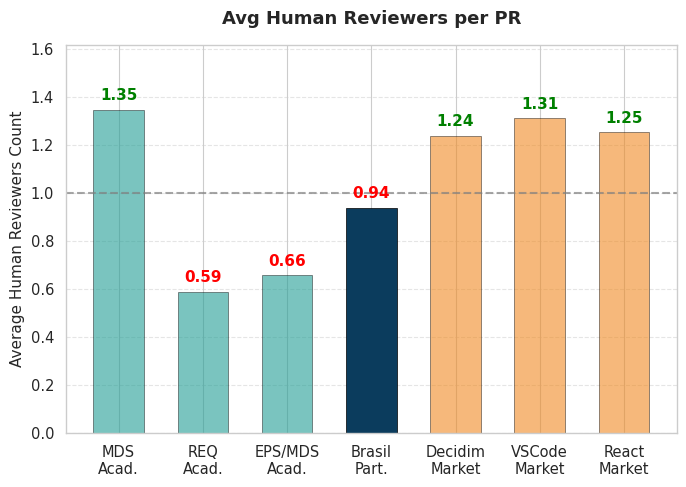

In [175]:
def count_human_reviewers(reviewers_str):
    if pd.isna(reviewers_str) or reviewers_str == '':
        return 0
    bot_kw = ['github-actions', 'github-advanced-security', 'copilot-pull-request-reviewer',
              'dependabot', 'renovate', 'codecov', 'bot', 'Edu_25']
    reviewers = [r.strip().lower() for r in str(reviewers_str).split(',')]
    return sum(1 for r in reviewers if not any(bot in r for bot in bot_kw))

# Removendo Edu_25 (senior dev do BP) para análise de cobertura de revisão, pois ele é um outlier que pode distorcer a percepção geral da cobertura de revisão no projeto.
df_no_bots_filter = df_no_bots[df_no_bots['author'] != 'Edu_25'].copy()

human_intensity_bp = df_no_bots_filter['reviewers'].apply(count_human_reviewers).mean()
human_intensity_mds = df_mds_no_bots['reviewers'].apply(count_human_reviewers).mean()
human_intensity_req = df_req_no_bots['reviewers'].apply(count_human_reviewers).mean()
human_intensity_epsmds = df_epsmds_no_bots['reviewers'].apply(count_human_reviewers).mean()
human_intensity_decidim = df_decidim_no_bots['reviewers'].apply(count_human_reviewers).mean()
human_intensity_vscode = df_vscode_no_bots['reviewers'].apply(count_human_reviewers).mean()
human_intensity_react = df_react_no_bots['reviewers'].apply(count_human_reviewers).mean()

x_labels = [
    "MDS\nAcad.", 
    "REQ\nAcad.", 
    "EPS/MDS\nAcad.",
    "Brasil\nPart.", 
    "Decidim\nMarket", 
    "VSCode\nMarket",
    "React\nMarket"
]
bar_colors = [DISC_PRIMARY, DISC_PRIMARY, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY]
bar_alphas = [0.6, 0.6, 0.6, 1.0, 0.6, 0.6, 0.6]

y_human_intensity = [human_intensity_mds, human_intensity_req, human_intensity_epsmds, human_intensity_bp,
                     human_intensity_decidim, human_intensity_vscode, human_intensity_react]

fig, ax1 = plt.subplots(figsize=(7, 5), dpi=100)

bars1 = ax1.bar(x_labels, y_human_intensity, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars1, bar_alphas):
    bar.set_alpha(alpha)

ax1.set_title('Avg Human Reviewers per PR', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylabel('Average Human Reviewers Count', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, max(y_human_intensity) * 1.2)
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for bar, val in zip(bars1, y_human_intensity):
    height = bar.get_height()
    color = 'red' if val < 1 else 'green'
    ax1.text(bar.get_x() + bar.get_width()/2., height + (max(y_human_intensity) * 0.02),
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

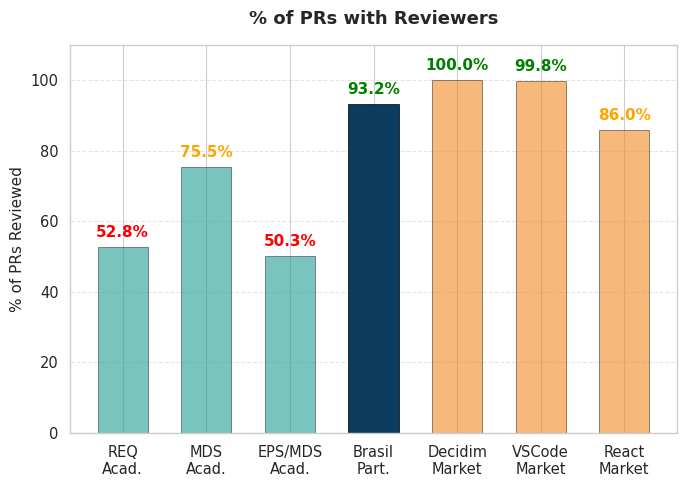

In [176]:
coverage_bp = (df_no_bots_filter['reviewers'].notna() & (df_no_bots_filter['reviewers'] != '')).mean() * 100
coverage_mds = (df_mds_no_bots['reviewers'].notna() & (df_mds_no_bots['reviewers'] != '')).mean() * 100
coverage_req = (df_req_no_bots['reviewers'].notna() & (df_req_no_bots['reviewers'] != '')).mean() * 100
coverage_epsmds = (df_epsmds_no_bots['reviewers'].notna() & (df_epsmds_no_bots['reviewers'] != '')).mean() * 100
coverage_decidim = (df_decidim_no_bots['reviewers'].notna() & (df_decidim_no_bots['reviewers'] != '')).mean() * 100
coverage_vscode = (df_vscode_no_bots['reviewers'].notna() & (df_vscode_no_bots['reviewers'] != '')).mean() * 100
coverage_react = (df_react_no_bots['reviewers'].notna() & (df_react_no_bots['reviewers'] != '')).mean() * 100

y_coverage = [coverage_req, coverage_mds, coverage_epsmds, coverage_bp, coverage_decidim, coverage_vscode, coverage_react]
x_labels_mod = [
    "REQ\nAcad.", 
    "MDS\nAcad.", 
    "EPS/MDS\nAcad.",
    "Brasil\nPart.", 
    "Decidim\nMarket", 
    "VSCode\nMarket",
    "React\nMarket"
]
bar_colors = [DISC_PRIMARY, DISC_PRIMARY, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY]
bar_alphas = [0.6, 0.6, 0.6, 1.0, 0.6, 0.6, 0.6]

fig, ax2 = plt.subplots(figsize=(7, 5), dpi=100)

bars2 = ax2.bar(x_labels_mod, y_coverage, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars2, bar_alphas):
    bar.set_alpha(alpha)

ax2.set_title('% of PRs with Reviewers', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('% of PRs Reviewed', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 110)

for bar, val in zip(bars2, y_coverage):
    height = bar.get_height()
    color = 'green' if val >= 90 else ('orange' if val >= 70 else 'red')
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

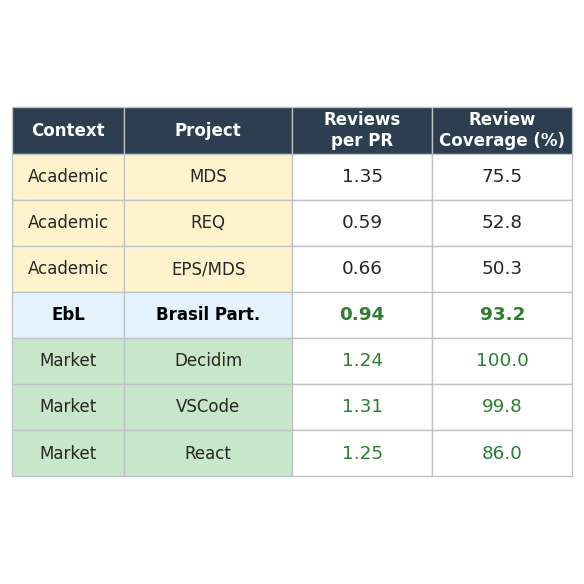

In [177]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
ax.axis('off')

columns = ['Context', 'Project', 'Reviews\nper PR', 'Review\nCoverage (%)']
rows_data = [
    ['Academic', 'MDS', f'{human_intensity_mds:.2f}', f'{coverage_mds:.1f}'],
    ['Academic', 'REQ', f'{human_intensity_req:.2f}', f'{coverage_req:.1f}'],
    ['Academic', 'EPS/MDS', f'{human_intensity_epsmds:.2f}', f'{coverage_epsmds:.1f}'],
    ['EbL', 'Brasil Part.', f'{human_intensity_bp:.2f}', f'{coverage_bp:.1f}'],
    ['Market', 'Decidim', f'{human_intensity_decidim:.2f}', f'{coverage_decidim:.1f}'],
    ['Market', 'VSCode', f'{human_intensity_vscode:.2f}', f'{coverage_vscode:.1f}'],
    ['Market', 'React', f'{human_intensity_react:.2f}', f'{coverage_react:.1f}'],
]

col_widths = [0.20, 0.30, 0.25, 0.25]

table = ax.table(
    cellText=rows_data,
    colLabels=columns,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.9)

HEADER_COLOR = '#2c3e50'
ACADEMIC_BG = '#fff3cd'
EBL_HIGHLIGHT = '#e3f2fd'
MARKET_BG = '#c8e6c9'
GREEN_TEXT = '#2e7d32'
YELLOW_TEXT = '#f57c00'
RED_TEXT = '#c62828'

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#bdc3c7')
    cell.set_linewidth(0.8)
    
    if row == 0:
        cell.set_text_props(fontweight='bold', color='white', fontsize=10)
        cell.set_facecolor(HEADER_COLOR)
    elif row == 4:  # EbL row (Brasil Part.)
        if col in [0, 1]:
            cell.set_facecolor(EBL_HIGHLIGHT)
            cell.set_text_props(fontweight='bold', color='black')
        else:
            cell.set_facecolor('white')
            cell.set_text_props(fontweight='bold', fontsize=11, color=GREEN_TEXT)
    elif row in [1, 2, 3]:  # Academic rows
        if col in [0, 1]:
            cell.set_facecolor(ACADEMIC_BG)
            cell.set_text_props(fontweight='normal')
        elif col == 2:
            cell.set_facecolor('white')
            cell.set_text_props(fontweight='normal', fontsize=11)
        elif col == 3:
            cell.set_facecolor('white')
            cell.set_text_props(fontweight='normal', fontsize=11)
    else:  # Market rows
        if col in [0, 1]:
            cell.set_facecolor(MARKET_BG)
            cell.set_text_props(fontweight='normal')
        else:
            cell.set_facecolor('white')
            cell.set_text_props(color=GREEN_TEXT, fontweight='normal', fontsize=11)

plt.tight_layout()
plt.show()

Brasil Part.         | Avg authors/file: 1.98 | Shared files: 43.2% | Total files: 1092
MDS Acad.            | Avg authors/file: 1.56 | Shared files: 33.2% | Total files: 1176
REQ Acad.            | Avg authors/file: 1.43 | Shared files: 32.2% | Total files: 944
EPS/MDS Acad.        | Avg authors/file: 1.43 | Shared files: 29.4% | Total files: 819
Decidim Market       | Avg authors/file: 1.59 | Shared files: 36.2% | Total files: 4162
VSCode Market        | Avg authors/file: 2.37 | Shared files: 49.3% | Total files: 6753
React Market         | Avg authors/file: 1.69 | Shared files: 32.4% | Total files: 3783


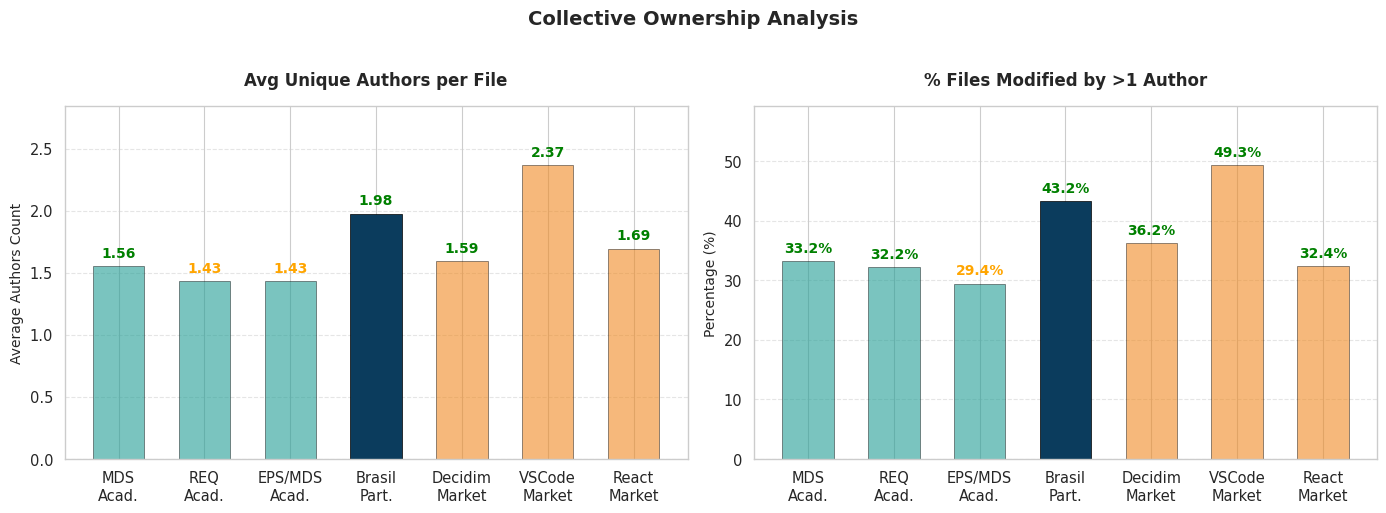

In [178]:
def analyze_file_ownership(df_project):
    """
    Analisa o collective ownership de um projeto.
    Retorna:
    - avg_authors_per_file: média de autores únicos por arquivo
    - shared_files_pct: % de arquivos modificados por mais de 1 autor
    - total_files: total de arquivos únicos (hashes)
    """
    # Mapear: file_hash -> set de autores que modificaram
    file_to_authors = {}
    
    for _, row in df_project.iterrows():
        author = row['author']
        file_hashes_str = row.get('file_hashes', '')
        
        if pd.isna(file_hashes_str) or file_hashes_str == '':
            continue
        
        # file_hashes é uma string com hashes separados por vírgula
        hashes = [h.strip() for h in str(file_hashes_str).split(',') if h.strip()]
        
        for fhash in hashes:
            if fhash not in file_to_authors:
                file_to_authors[fhash] = set()
            file_to_authors[fhash].add(author)
    
    if not file_to_authors:
        return 0, 0, 0
    
    # Calcular métricas
    authors_per_file = [len(authors) for authors in file_to_authors.values()]
    avg_authors = np.mean(authors_per_file)
    shared_files_count = sum(1 for authors in file_to_authors.values() if len(authors) > 1)
    shared_files_pct = (shared_files_count / len(file_to_authors)) * 100 if len(file_to_authors) > 0 else 0
    
    return avg_authors, shared_files_pct, len(file_to_authors)

# Analisar cada projeto
projects_analysis = {}
for project_name, df_proj in [
    ('Brasil Part.', df_no_bots),
    ('MDS Acad.', df_mds_no_bots),
    ('REQ Acad.', df_req_no_bots),
    ('EPS/MDS Acad.', df_epsmds_no_bots),
    ('Decidim Market', df_decidim_no_bots),
    ('VSCode Market', df_vscode_no_bots),
    ('React Market', df_react_no_bots),
]:
    avg_auth, shared_pct, total_files = analyze_file_ownership(df_proj)
    projects_analysis[project_name] = {
        'avg_authors': avg_auth,
        'shared_pct': shared_pct,
        'total_files': total_files
    }
    print(f"{project_name:20s} | Avg authors/file: {avg_auth:.2f} | Shared files: {shared_pct:.1f}% | Total files: {total_files}")

# Gráfico de barras comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

project_labels = ['MDS\nAcad.', 'REQ\nAcad.', 'EPS/MDS\nAcad.', 'Brasil\nPart.', 'Decidim\nMarket', 'VSCode\nMarket', 'React\nMarket']
project_keys = ['MDS Acad.', 'REQ Acad.', 'EPS/MDS Acad.', 'Brasil Part.', 'Decidim Market', 'VSCode Market', 'React Market']

avg_authors_values = [projects_analysis[k]['avg_authors'] for k in project_keys]
shared_files_values = [projects_analysis[k]['shared_pct'] for k in project_keys]

bar_colors = [DISC_PRIMARY, DISC_PRIMARY, DISC_PRIMARY, BP_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY, BENCH_PRIMARY]
bar_alphas = [0.6, 0.6, 0.6, 1.0, 0.6, 0.6, 0.6]

# Subplot 1: Average Authors per File
bars1 = ax1.bar(project_labels, avg_authors_values, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars1, bar_alphas):
    bar.set_alpha(alpha)

ax1.set_title('Avg Unique Authors per File', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Average Authors Count', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, max(avg_authors_values) * 1.2)

for bar, val in zip(bars1, avg_authors_values):
    height = bar.get_height()
    color_text = 'green' if val > 1.5 else 'orange'
    ax1.text(bar.get_x() + bar.get_width()/2., height + (max(avg_authors_values) * 0.02),
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_text)

# Subplot 2: Shared Files Percentage
bars2 = ax2.bar(project_labels, shared_files_values, color=bar_colors, width=0.6, edgecolor='black', linewidth=0.5)
for bar, alpha in zip(bars2, bar_alphas):
    bar.set_alpha(alpha)

ax2.set_title('% Files Modified by >1 Author', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('Percentage (%)', fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.set_ylim(0, max(shared_files_values) * 1.2)

for bar, val in zip(bars2, shared_files_values):
    height = bar.get_height()
    color_text = 'green' if val > 30 else 'orange'
    ax2.text(bar.get_x() + bar.get_width()/2., height + (max(shared_files_values) * 0.02),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_text)

plt.suptitle('Collective Ownership Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

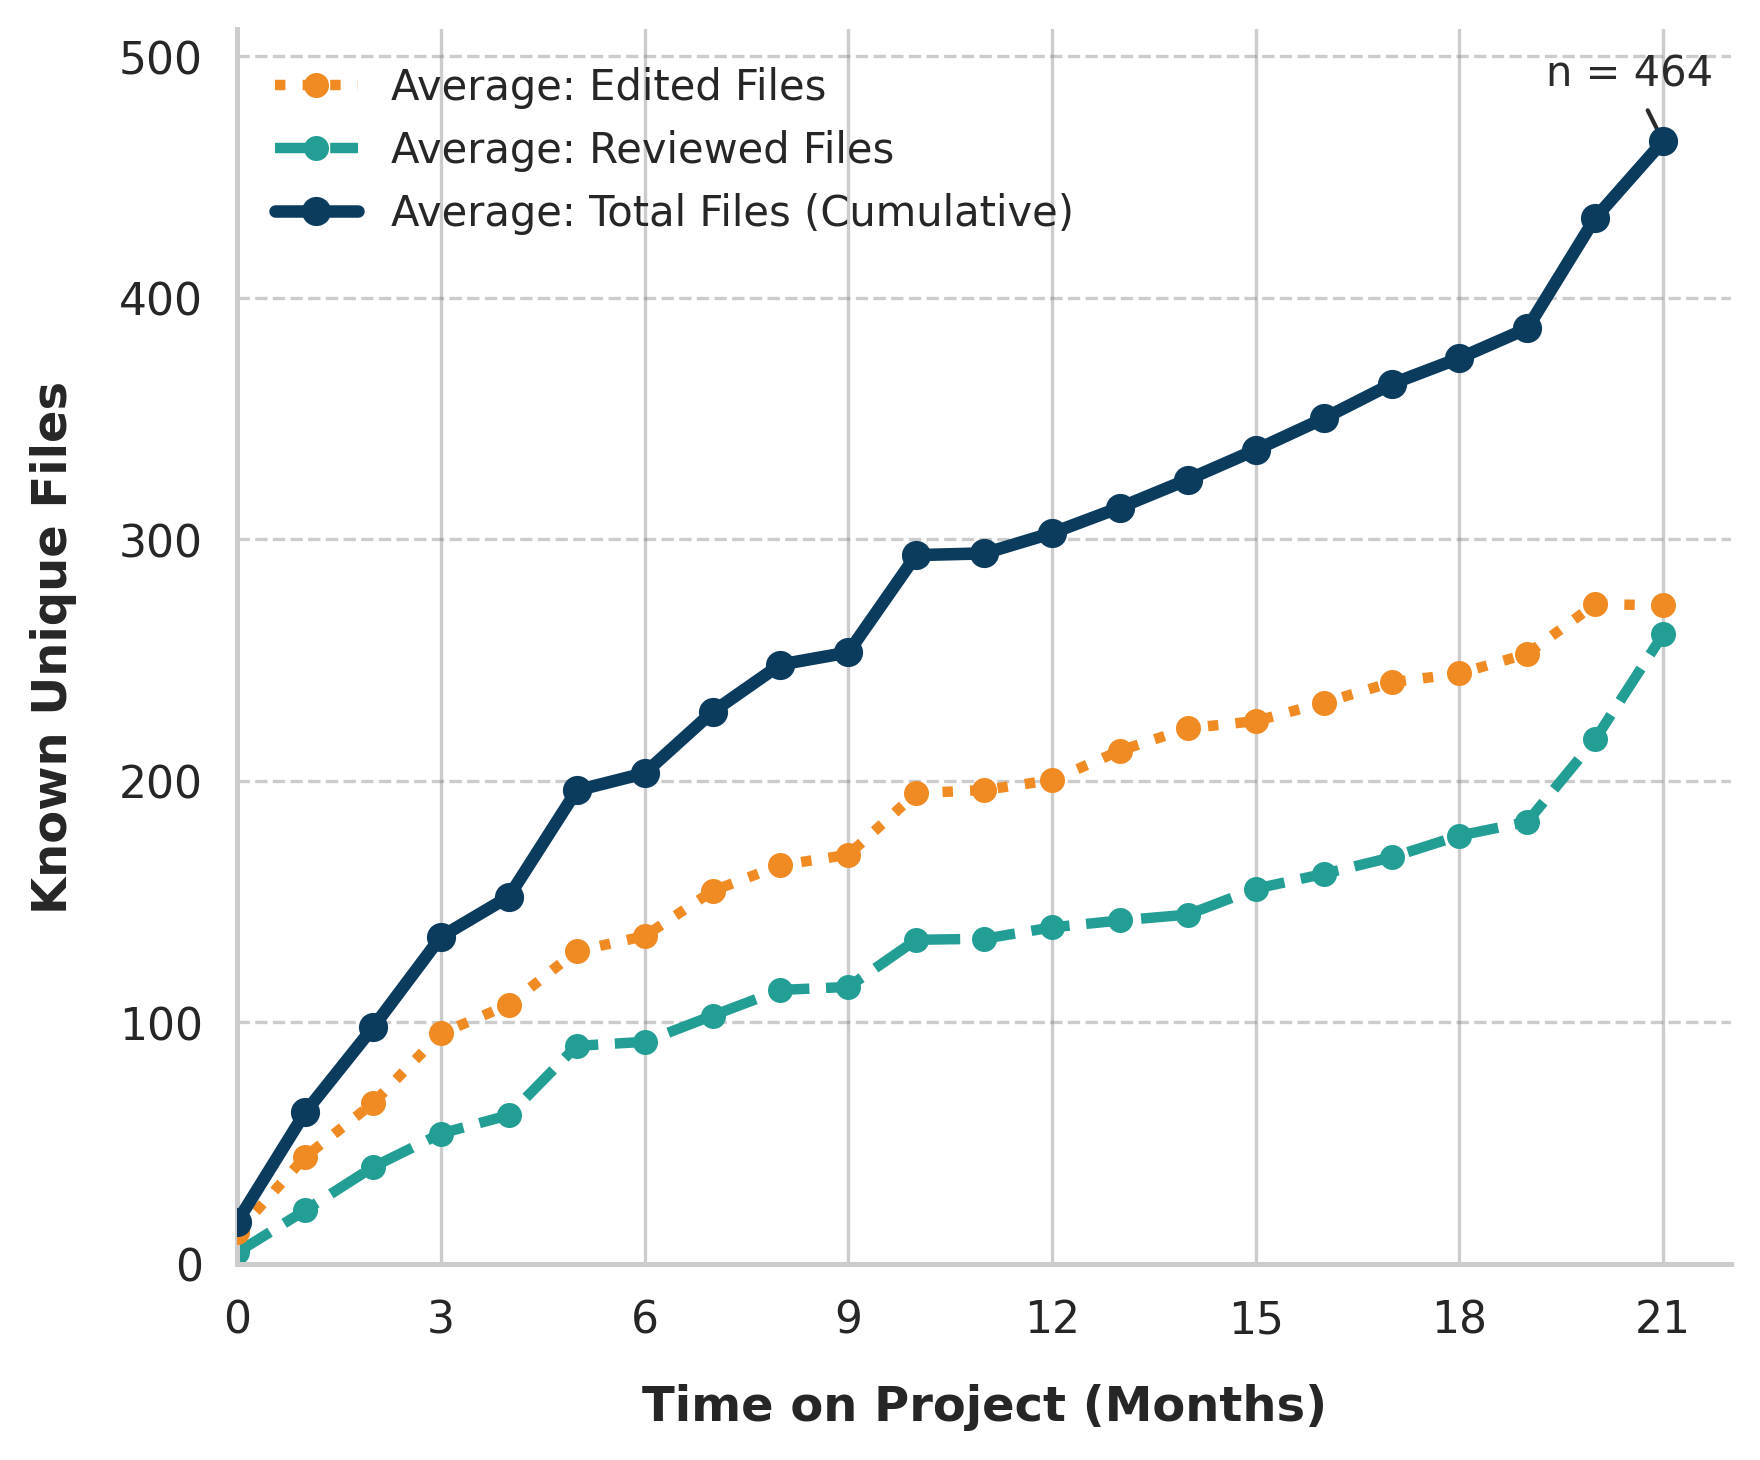

In [179]:
def analyze_knowledge_growth(df_project, min_devs=3):
    df = df_project.copy()
    df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
    df = df[df['created_at'].notna()].copy()
    df = df.sort_values('created_at')
    
    dev_timeline = {}
    
    # === FASE 1: Coletar eventos de cada desenvolvedor ===
    
    # Processar PRs como autor
    for _, row in df.iterrows():
        author = row['author']
        if pd.isna(author) or is_bot_author(author):
            continue
        timestamp = row['created_at']
        file_hashes_str = row.get('file_hashes', '')
        if pd.isna(file_hashes_str) or file_hashes_str == '':
            continue
        files = set([h.strip() for h in str(file_hashes_str).split(',') if h.strip()])
        if author not in dev_timeline:
            dev_timeline[author] = {'events': [], 'first_contribution': timestamp}
        dev_timeline[author]['events'].append({
            'timestamp': timestamp,
            'files_edited': files,
            'files_reviewed': set()
        })
    
    # Processar PRs como revisor
    for _, row in df.iterrows():
        reviewers_str = row.get('reviewers', '')
        if pd.isna(reviewers_str) or reviewers_str == '':
            continue
        timestamp = row['created_at']
        file_hashes_str = row.get('file_hashes', '')
        if pd.isna(file_hashes_str) or file_hashes_str == '':
            continue
        files = set([h.strip() for h in str(file_hashes_str).split(',') if h.strip()])
        reviewers = [r.strip() for r in str(reviewers_str).split(',') if r.strip()]
        for reviewer in reviewers:
            if is_bot_author(reviewer):
                continue
            if reviewer not in dev_timeline:
                dev_timeline[reviewer] = {'events': [], 'first_contribution': timestamp}
            if timestamp < dev_timeline[reviewer]['first_contribution']:
                dev_timeline[reviewer]['first_contribution'] = timestamp
            dev_timeline[reviewer]['events'].append({
                'timestamp': timestamp,
                'files_edited': set(),
                'files_reviewed': files
            })
    
    dev_monthly_data = {}  # dev -> {month: {edited, reviewed, total}}
    
    for dev, data in dev_timeline.items():
        first_contrib = data['first_contribution']
        events = sorted(data['events'], key=lambda x: x['timestamp'])
        
        # Acumuladores
        files_edited_seen = set()
        files_reviewed_seen = set()
        
        raw_months = {}  # tenure_bin -> último estado acumulado
        
        for event in events:
            files_edited_seen.update(event['files_edited'])
            files_reviewed_seen.update(event['files_reviewed'])
            
            tenure_days = (event['timestamp'] - first_contrib).days
            tenure_bin = int(tenure_days / 30.44)
            
            # Sempre sobrescrever: queremos o ÚLTIMO estado de cada mês
            raw_months[tenure_bin] = {
                'files_edited': len(files_edited_seen),
                'files_reviewed': len(files_reviewed_seen),
                'files_total': len(files_edited_seen | files_reviewed_seen)
            }
        
        if not raw_months:
            continue
        
        first_month = min(raw_months.keys())
        last_month = max(raw_months.keys())
        
        filled_months = {}
        prev_state = {'files_edited': 0, 'files_reviewed': 0, 'files_total': 0}
        
        for m in range(first_month, last_month + 1):
            if m in raw_months:
                prev_state = raw_months[m]
            filled_months[m] = prev_state.copy()
        
        dev_monthly_data[dev] = filled_months
    
    
    all_months = set()
    for dm in dev_monthly_data.values():
        all_months.update(dm.keys())
    
    results = []
    for tenure_month in sorted(all_months):
        edited_vals = []
        reviewed_vals = []
        total_vals = []
        devs_in_month = []
        
        for dev, monthly_data in dev_monthly_data.items():
            if tenure_month in monthly_data:
                devs_in_month.append(dev)
                edited_vals.append(monthly_data[tenure_month]['files_edited'])
                reviewed_vals.append(monthly_data[tenure_month]['files_reviewed'])
                total_vals.append(monthly_data[tenure_month]['files_total'])
        
        num_devs = len(devs_in_month)
        if num_devs < min_devs:
            continue
        
        results.append({
            'tenure_month': tenure_month,
            'num_devs': num_devs,
            'mean_edited': np.mean(edited_vals),
            'mean_reviewed': np.mean(reviewed_vals),
            'mean_total': np.mean(total_vals),
            'std_total': np.std(total_vals),
        })
    
    return pd.DataFrame(results), dev_monthly_data

results_corrected, dev_data_corrected = analyze_knowledge_growth(df_no_bots, min_devs=3)

fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.plot(
    results_corrected['tenure_month'],
    results_corrected['mean_edited'],
    linestyle=':',
    linewidth=2.5,
    marker='o',
    markersize=5,
    color=BENCH_PRIMARY,
    label='Average: Edited Files',
    zorder=3
)

ax.plot(
    results_corrected['tenure_month'],
    results_corrected['mean_reviewed'],
    linestyle='--',
    linewidth=2.5,
    marker='o',
    markersize=5,
    color=DISC_PRIMARY,
    label='Average: Reviewed Files',
    zorder=2
)

ax.plot(
    results_corrected['tenure_month'],
    results_corrected['mean_total'],
    linestyle='-',
    linewidth=3,
    marker='o',
    markersize=6,
    color=BP_PRIMARY,
    label='Average: Total Files (Cumulative)',
    zorder=4
)

ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray', zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel('Time on Project (Months)', labelpad=10, fontweight='bold')
ax.set_ylabel('Known Unique Files', labelpad=10, fontweight='bold')

ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
ax.legend(loc='upper left', frameon=False, fontsize=10)

ax.set_xlim(0, results_corrected['tenure_month'].max() + 1)
ax.set_ylim(0, results_corrected['mean_total'].max() * 1.1)

last_month = results_corrected['tenure_month'].iloc[-1]
last_total = results_corrected['mean_total'].iloc[-1]
ax.annotate(
    f'n = {int(last_total)}',
    xy=(last_month, last_total),
    xytext=(last_month - 0.5, last_total + (results_corrected['mean_total'].max() * 0.05)),
    fontsize=10,
    color=color_total,
    ha='center',
    arrowprops=dict(arrowstyle='-', color=color_total, lw=1)
)

plt.tight_layout()
plt.show()

 <img src="assets/grafo.png" width="1000" />

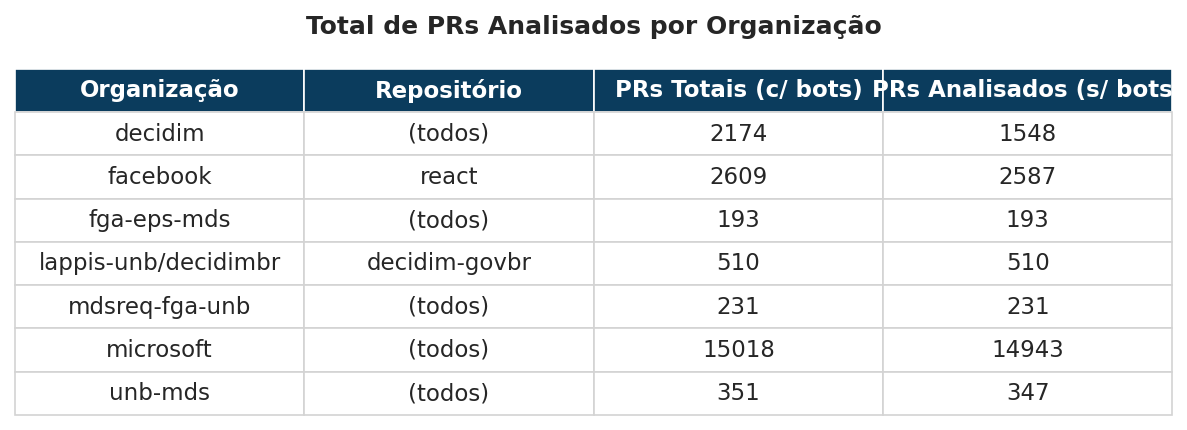

In [180]:
# Gerando uma tabela formatada como imagem (matplotlib) para o artigo
fig, ax = plt.subplots(figsize=(8, 3), dpi=150)
ax.axis('tight')
ax.axis('off')

# Renomeando colunas para a tabela final
plot_df = prs_counts.rename(columns={
    'org': 'Organização',
    'repo': 'Repositório',
    'prs_total': 'PRs Totais (c/ bots)',
    'prs_sem_bots': 'PRs Analisados (s/ bots)'
})

# Pegando os dados
cell_text = plot_df.values
columns = plot_df.columns

table = ax.table(cellText=cell_text, colLabels=columns, loc='center', cellLoc='center')

# Desabilitar o autoset de fonte para podermos forçar um tamanho
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Estilizando o cabeçalho usando as cores do artigo
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(BP_PRIMARY)
        cell.set_edgecolor('white')
    else:
        cell.set_edgecolor('lightgray')

plt.title('Total de PRs Analisados por Organização', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()